# DATATHON 2026 - Round 1
## Part 2 - Visualization and Data Analysis

**Team:** `<CT-PTIT/> CapyData`

Mạch phân tích của một doanh nghiệp thời trang thương mại điện tử:

1. Revenue, COGS và gross margin theo thời gian.
2. Product portfolio: category/segment nào tạo lợi nhuận có chất lượng.
3. Promotion effectiveness: khuyến mãi tạo giá trị hay làm mỏng margin.
4. Customer retention và nhóm khách hàng.
5. Returns, delivery và customer experience.
6. Web traffic như tín hiệu nhu cầu.
7. Inventory risk: stockout và overstock.
8. Tổng hợp khuyến nghị hành động.


In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path(".")
FIG_DIR = Path("eda_figures")
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="Set2",
    font_scale=1.05,
)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

COLOR_MAIN = "#2563eb"
COLOR_GREEN = "#16a34a"
COLOR_ORANGE = "#f97316"
COLOR_RED = "#dc2626"
COLOR_PURPLE = "#7c3aed"
COLOR_GRAY = "#475569"


def safe_divide(num, den):
    num = np.asarray(num, dtype="float64")
    den = np.asarray(den, dtype="float64")
    return np.divide(num, den, out=np.full_like(num, np.nan, dtype="float64"), where=den != 0)


def money(x):
    if pd.isna(x):
        return "NA"
    x = float(x)
    abs_x = abs(x)
    if abs_x >= 1e12:
        return f"{x / 1e12:,.2f}T"
    if abs_x >= 1e9:
        return f"{x / 1e9:,.2f}B"
    if abs_x >= 1e6:
        return f"{x / 1e6:,.2f}M"
    if abs_x >= 1e3:
        return f"{x / 1e3:,.1f}K"
    return f"{x:,.0f}"


def pct(x, digits=1):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}%}"


def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


def format_money_axis(ax, axis="y"):
    formatter = mtick.FuncFormatter(lambda x, _: money(x))
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def style_bubble_legend(ax, loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, max_marker_area=220):
    """Keep Seaborn hue/size legends readable when bubble markers are large."""
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return None

    legend = ax.legend(
        handles=handles,
        labels=labels,
        loc=loc,
        bbox_to_anchor=bbox_to_anchor,
        ncol=ncol,
        borderaxespad=0.0,
        borderpad=0.8,
        labelspacing=1.35,
        handleheight=2.2,
        handletextpad=0.9,
        columnspacing=1.3,
        markerscale=0.75,
        scatterpoints=1,
        frameon=False,
    )

    legend_handles = getattr(legend, "legend_handles", getattr(legend, "legendHandles", []))
    for handle in legend_handles:
        if hasattr(handle, "get_sizes") and hasattr(handle, "set_sizes"):
            sizes = handle.get_sizes()
            if len(sizes):
                handle.set_sizes(np.clip(sizes, 20, max_marker_area))
        if hasattr(handle, "set_alpha"):
            handle.set_alpha(0.85)
    return legend


def display_insight(title, bullets, action):
    text = [f"### {title}", ""]
    text.extend([f"- {item}" for item in bullets])
    text.append("")
    text.append(f"**Business implication / action:** {action}")
    display(Markdown("\n".join(text)))


def display_table(df, money_cols=None, pct_cols=None, int_cols=None, float_cols=None, n=None):
    out = df.head(n).copy() if n else df.copy()
    money_cols = money_cols or []
    pct_cols = pct_cols or []
    int_cols = int_cols or []
    float_cols = float_cols or {}

    for col in money_cols:
        if col in out.columns:
            out[col] = out[col].map(money)
    for col in pct_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x, 2))
    for col in int_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "NA")
    for col, digits in float_cols.items():
        if col in out.columns:
            out[col] = out[col].map(lambda x, d=digits: f"{x:,.{d}f}" if pd.notna(x) else "NA")

    display(out)


## 1. Data loading

Đọc các bảng dữ liệu master, transaction, analytical và operational. Các bảng này được dùng để dựng chỉ số bán hàng, sản phẩm, khuyến mãi, vận hành và traffic.

In [2]:
products = pd.read_csv(DATA_DIR / "products.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
geography = pd.read_csv(DATA_DIR / "geography.csv")

orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])

sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
web = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

tables = {
    "products": products,
    "customers": customers,
    "promotions": promotions,
    "geography": geography,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "sales": sales,
    "inventory": inventory,
    "web_traffic": web,
}

date_cols = {
    "customers": "signup_date",
    "promotions": "start_date",
    "orders": "order_date",
    "shipments": "ship_date",
    "returns": "return_date",
    "reviews": "review_date",
    "sales": "Date",
    "inventory": "snapshot_date",
    "web_traffic": "date",
}

summary = []
for name, df in tables.items():
    date_col = date_cols.get(name)
    summary.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_pct": df.isna().mean().mean(),
        "date_min": df[date_col].min().date() if date_col else "",
        "date_max": df[date_col].max().date() if date_col else "",
    })

summary_df = pd.DataFrame(summary)
display_table(summary_df, int_cols=["rows", "columns"], pct_cols=["missing_pct"])

key_checks = pd.DataFrame([
    ["products: cogs < price", (products["cogs"] < products["price"]).all()],
    ["payments: one row per order", payments["order_id"].is_unique and payments["order_id"].nunique() == orders["order_id"].nunique()],
    ["order_items product_id exists", order_items["product_id"].isin(products["product_id"]).all()],
    ["orders zip exists", orders["zip"].isin(geography["zip"]).all()],
], columns=["check", "passed"])
display(key_checks)


,table,rows,columns,missing_pct,date_min,date_max
0,products,"2,412",8,0.00%,,
1,customers,"121,930",7,0.00%,2012-01-17,2022-12-31
2,promotions,50,10,8.00%,2013-01-31,2022-11-18
3,geography,"39,948",4,0.00%,,
4,orders,"646,945",8,0.00%,2012-07-04,2022-12-31
5,order_items,"714,669",7,23.04%,,
6,payments,"646,945",4,0.00%,,
7,shipments,"566,067",4,0.00%,2012-07-04,2022-12-29
8,returns,"39,939",7,0.00%,2012-07-11,2022-12-31
9,reviews,"113,551",7,0.00%,2012-07-10,2022-12-31


,check,passed
0,products: cogs < price,True
1,payments: one row per order,True
2,order_items product_id exists,True
3,orders zip exists,True


## 2. Analytical table ở cấp dòng sản phẩm

Để phân tích xuyên bảng, ta tạo `item_df` ở grain: **một sản phẩm trong một đơn hàng**. Bảng này kết hợp order item, product, order, customer, geography, payment, shipment, return và review.

Các đơn `cancelled` được loại khỏi `commercial_df` khi phân tích revenue/margin vì đó không phải doanh thu thực tế.


In [3]:
orders_geo = orders.merge(
    geography.rename(columns={"city": "geo_city"}),
    on="zip",
    how="left",
)

return_agg = returns.groupby(["order_id", "product_id"], as_index=False).agg(
    returned_qty=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum"),
    return_records=("return_id", "count"),
)

review_agg = reviews.groupby(["order_id", "product_id"], as_index=False).agg(
    avg_rating=("rating", "mean"),
    review_count=("review_id", "count"),
)

item_df = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(orders_geo, on="order_id", how="left")
    .merge(customers[["customer_id", "signup_date", "gender", "age_group", "acquisition_channel"]],
           on="customer_id", how="left")
    .merge(payments[["order_id", "payment_value", "installments"]], on="order_id", how="left")
    .merge(shipments, on="order_id", how="left")
    .merge(return_agg, on=["order_id", "product_id"], how="left")
    .merge(review_agg, on=["order_id", "product_id"], how="left")
)

for col in ["returned_qty", "refund_amount", "return_records", "review_count"]:
    item_df[col] = item_df[col].fillna(0)

item_df["gross_revenue"] = item_df["quantity"] * item_df["unit_price"]
item_df["net_revenue"] = item_df["gross_revenue"] - item_df["discount_amount"]
item_df["line_cogs"] = item_df["quantity"] * item_df["cogs"]
item_df["gross_profit"] = item_df["net_revenue"] - item_df["line_cogs"]
item_df["gross_margin_rate"] = safe_divide(item_df["gross_profit"], item_df["net_revenue"])
item_df["discount_rate"] = safe_divide(item_df["discount_amount"], item_df["gross_revenue"])
item_df["return_flag"] = (item_df["returned_qty"] > 0).astype(int)
item_df["unit_return_rate"] = safe_divide(item_df["returned_qty"], item_df["quantity"])
item_df["has_promo"] = item_df["promo_id"].notna()
item_df["has_second_promo"] = item_df["promo_id_2"].notna()
item_df["delivery_days"] = (item_df["delivery_date"] - item_df["ship_date"]).dt.days
item_df["order_year"] = item_df["order_date"].dt.year
item_df["order_month"] = item_df["order_date"].dt.month
item_df["order_year_month"] = item_df["order_date"].dt.to_period("M").dt.to_timestamp()
item_df["is_cancelled"] = item_df["order_status"].eq("cancelled")

commercial_df = item_df.loc[~item_df["is_cancelled"]].copy()

overview = pd.DataFrame({
    "metric": [
        "item-level rows",
        "commercial rows",
        "cancelled line share",
        "promo line share",
        "returned line share",
        "avg gross margin",
    ],
    "value": [
        f"{len(item_df):,.0f}",
        f"{len(commercial_df):,.0f}",
        pct(item_df["is_cancelled"].mean()),
        pct(item_df["has_promo"].mean()),
        pct(item_df["return_flag"].mean()),
        pct(commercial_df["gross_margin_rate"].mean()),
    ],
})
display(overview)
display(commercial_df.head())


,metric,value
0,item-level rows,"714,669"
1,commercial rows,"648,996"
2,cancelled line share,9.2%
3,promo line share,38.7%
4,returned line share,5.6%
5,avg gross margin,7.1%


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,geo_city,region,district,signup_date,gender,age_group,acquisition_channel,payment_value,installments,ship_date,delivery_date,shipping_fee,returned_qty,refund_amount,return_records,avg_rating,review_count,gross_revenue,net_revenue,line_cogs,gross_profit,gross_margin_rate,discount_rate,return_flag,unit_return_rate,has_promo,has_second_promo,delivery_days,order_year,order_month,order_year_month,is_cancelled
0,1,2400,7,"1,138.22",0.00,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.26","1,053.80",2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,Hanoi,East,District #02,2020-06-06,Female,35-44,social_media,"7,967.54",3,2012-07-07,2012-07-11,1.37,0.00,0.00,0.00,5.00,1.00,"7,967.54","7,967.54","7,376.59",590.95,0.07,0.00,0,0.00,False,False,4.00,2012,7,2012-07-01,False
1,2,609,7,"10,166.25",0.00,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",2012-07-04,58621,1330,returned,cod,mobile,paid_search,Phu Ly,East,District #02,2021-11-03,Female,18-24,social_media,"71,163.75",1,2012-07-06,2012-07-10,2.60,6.00,"52,458.01",1.00,NaN,0.00,"71,163.75","71,163.75","62,913.93","8,249.82",0.12,0.00,1,0.86,False,False,4.00,2012,7,2012-07-01,False
2,3,396,3,"11,220.33",0.00,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.43","10,091.01",2012-07-04,58811,1473,delivered,credit_card,desktop,direct,Lao Cai,East,District #02,2020-09-18,Female,35-44,direct,"33,660.99",3,2012-07-04,2012-07-07,2.38,0.00,0.00,0.00,5.00,1.00,"33,660.99","33,660.99","30,273.04","3,387.95",0.10,0.00,0,0.00,False,False,3.00,2012,7,2012-07-01,False
3,4,635,5,"10,639.25",0.00,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.22","9,205.43",2012-07-04,59453,2360,delivered,credit_card,desktop,referral,Son Tay,East,District #02,2016-05-29,Male,45-54,direct,"53,196.25",3,2012-07-05,2012-07-11,2.49,0.00,0.00,0.00,NaN,0.00,"53,196.25","53,196.25","46,027.15","7,169.10",0.13,0.00,0,0.00,False,False,6.00,2012,7,2012-07-01,False
4,6,1935,1,"1,597.84",0.00,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.91","1,048.70",2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,Uong Bi,East,District #02,2017-07-11,Male,18-24,social_media,"1,597.84",1,2012-07-09,2012-07-16,25.79,0.00,0.00,0.00,NaN,0.00,"1,597.84","1,597.84","1,048.70",549.14,0.34,0.00,0,0.00,False,False,7.00,2012,7,2012-07-01,False


## 3. Insight 1 - Revenue và gross margin dynamics

**Business question:** Doanh nghiệp tăng trưởng ra sao, mùa vụ nằm ở đâu và liệu tăng trưởng có đi cùng lợi nhuận không?


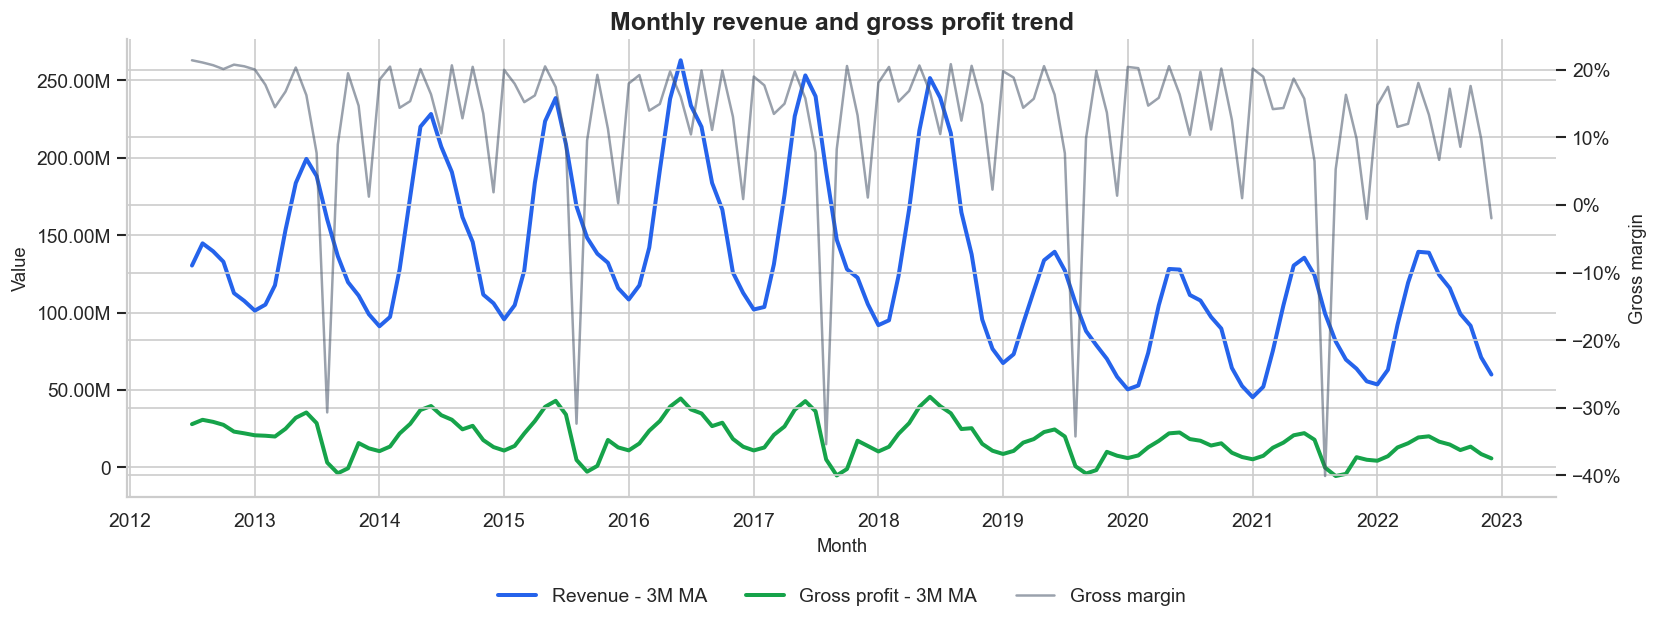

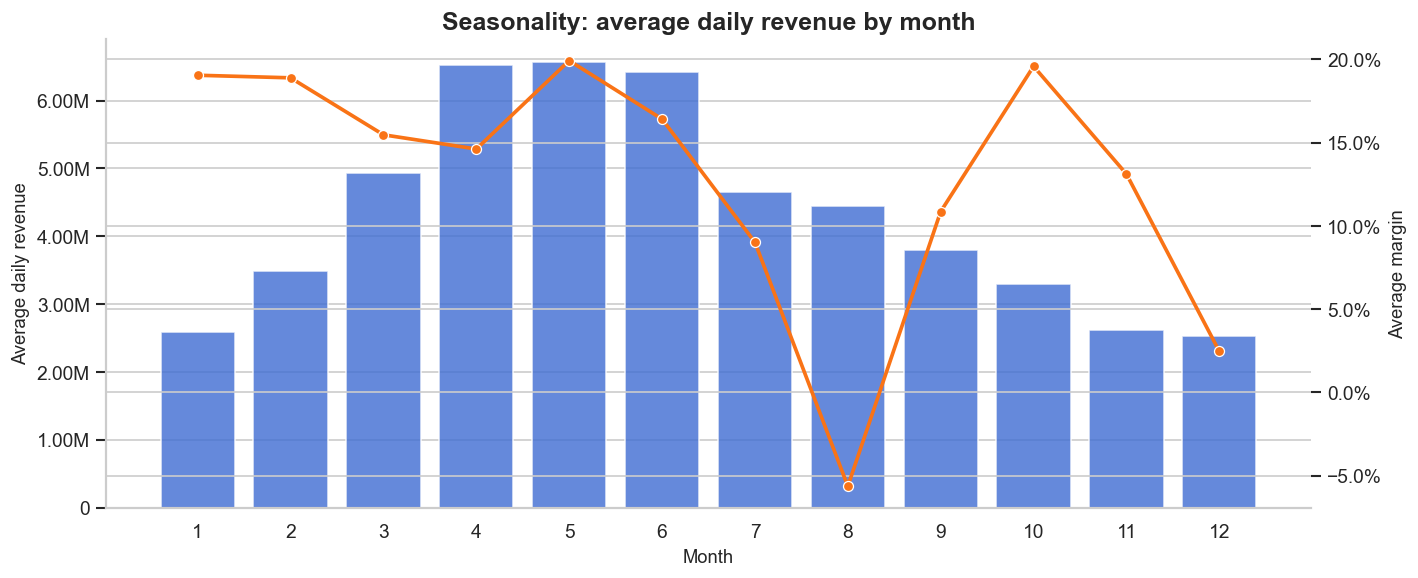

### Insight 1 - Growth phải đọc cùng margin

- Tháng doanh thu cao nhất là **2018-06** với **271.67M**.
- Năm doanh thu cao nhất là **2016**, đạt **2.10B** với margin **15.4%**.
- Tháng margin thấp nhất là **2021-08**, margin chỉ **-40.1%**.
- Theo seasonal profile, tháng **5** có doanh thu trung bình/ngày cao nhất: **6.58M**.

**Business implication / action:** Lên kế hoạch tồn kho, logistics và chiến dịch trước tháng seasonal peak, đồng thời đặt margin guardrail cho các tháng revenue cao nhưng margin giảm.

,year,revenue,gross_profit,margin_rate,yoy_growth
0,2012,741.50M,154.04M,20.77%,NA
1,2013,1.66B,191.19M,11.54%,123.49%
2,2014,1.87B,297.24M,15.88%,12.95%
3,2015,1.89B,224.49M,11.88%,0.97%
4,2016,2.10B,324.08M,15.40%,11.36%
5,2017,1.91B,216.78M,11.34%,-9.19%
6,2018,1.85B,307.95M,16.64%,-3.19%
7,2019,1.14B,131.60M,11.58%,-38.56%
8,2020,1.05B,168.43M,15.97%,-7.24%
9,2021,1.04B,101.91M,9.77%,-1.09%


In [4]:
sales2 = sales.sort_values("Date").copy()
sales2["gross_profit"] = sales2["Revenue"] - sales2["COGS"]
sales2["margin_rate"] = safe_divide(sales2["gross_profit"], sales2["Revenue"])
sales2["year"] = sales2["Date"].dt.year
sales2["month"] = sales2["Date"].dt.month
sales2["year_month"] = sales2["Date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = sales2.groupby("year_month", as_index=False).agg(
    revenue=("Revenue", "sum"),
    cogs=("COGS", "sum"),
    gross_profit=("gross_profit", "sum"),
)
monthly_sales["margin_rate"] = safe_divide(monthly_sales["gross_profit"], monthly_sales["revenue"])
monthly_sales["revenue_ma3"] = monthly_sales["revenue"].rolling(3, min_periods=1).mean()
monthly_sales["profit_ma3"] = monthly_sales["gross_profit"].rolling(3, min_periods=1).mean()

yearly_sales = sales2.groupby("year", as_index=False).agg(
    revenue=("Revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
)
yearly_sales["margin_rate"] = safe_divide(yearly_sales["gross_profit"], yearly_sales["revenue"])
yearly_sales["yoy_growth"] = yearly_sales["revenue"].pct_change()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="year_month", y="revenue_ma3", ax=ax1, label="Revenue - 3M MA", linewidth=2.4, color=COLOR_MAIN)
sns.lineplot(data=monthly_sales, x="year_month", y="profit_ma3", ax=ax1, label="Gross profit - 3M MA", linewidth=2.4, color=COLOR_GREEN)
ax1.set_title("Monthly revenue and gross profit trend")
ax1.set_xlabel("Month")
ax1.set_ylabel("Value")
format_money_axis(ax1)
ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax2 = ax1.twinx()
sns.lineplot(data=monthly_sales, x="year_month", y="margin_rate", ax=ax2, label="Gross margin", color=COLOR_GRAY, alpha=0.55)
ax2.set_ylabel("Gross margin")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1))
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
for axis in (ax1, ax2):
    legend = axis.get_legend()
    if legend is not None:
        legend.remove()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
savefig("part2_01_revenue_margin_trend.png")
plt.show()

seasonality = sales2.groupby("month", as_index=False).agg(
    avg_daily_revenue=("Revenue", "mean"),
    avg_margin=("margin_rate", "mean"),
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=seasonality, x="month", y="avg_daily_revenue", color=COLOR_MAIN, alpha=0.80, ax=ax)
ax.set_title("Seasonality: average daily revenue by month")
ax.set_xlabel("Month")
ax.set_ylabel("Average daily revenue")
format_money_axis(ax)
ax2 = ax.twinx()
sns.lineplot(data=seasonality, x=np.arange(12), y="avg_margin", marker="o", color=COLOR_ORANGE, linewidth=2.2, ax=ax2)
ax2.set_ylabel("Average margin")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout()
savefig("part2_02_revenue_seasonality.png")
plt.show()

peak_month = monthly_sales.loc[monthly_sales["revenue"].idxmax()]
low_margin_month = monthly_sales.loc[monthly_sales["margin_rate"].idxmin()]
best_year = yearly_sales.loc[yearly_sales["revenue"].idxmax()]
seasonal_peak = seasonality.loc[seasonality["avg_daily_revenue"].idxmax()]

display_insight(
    "Insight 1 - Growth phải đọc cùng margin",
    [
        f"Tháng doanh thu cao nhất là **{peak_month['year_month'].strftime('%Y-%m')}** với **{money(peak_month['revenue'])}**.",
        f"Năm doanh thu cao nhất là **{int(best_year['year'])}**, đạt **{money(best_year['revenue'])}** với margin **{pct(best_year['margin_rate'])}**.",
        f"Tháng margin thấp nhất là **{low_margin_month['year_month'].strftime('%Y-%m')}**, margin chỉ **{pct(low_margin_month['margin_rate'])}**.",
        f"Theo seasonal profile, tháng **{int(seasonal_peak['month'])}** có doanh thu trung bình/ngày cao nhất: **{money(seasonal_peak['avg_daily_revenue'])}**.",
    ],
    "Lên kế hoạch tồn kho, logistics và chiến dịch trước tháng seasonal peak, đồng thời đặt margin guardrail cho các tháng revenue cao nhưng margin giảm.",
)
display_table(yearly_sales, money_cols=["revenue", "gross_profit"], pct_cols=["margin_rate", "yoy_growth"])


## 4. Insight 2 - Product portfolio: lợi nhuận chất lượng nằm ở đâu?

**Business question:** Category/segment nào vừa tạo doanh thu, vừa giữ margin tốt, vừa ít rủi ro trả hàng?


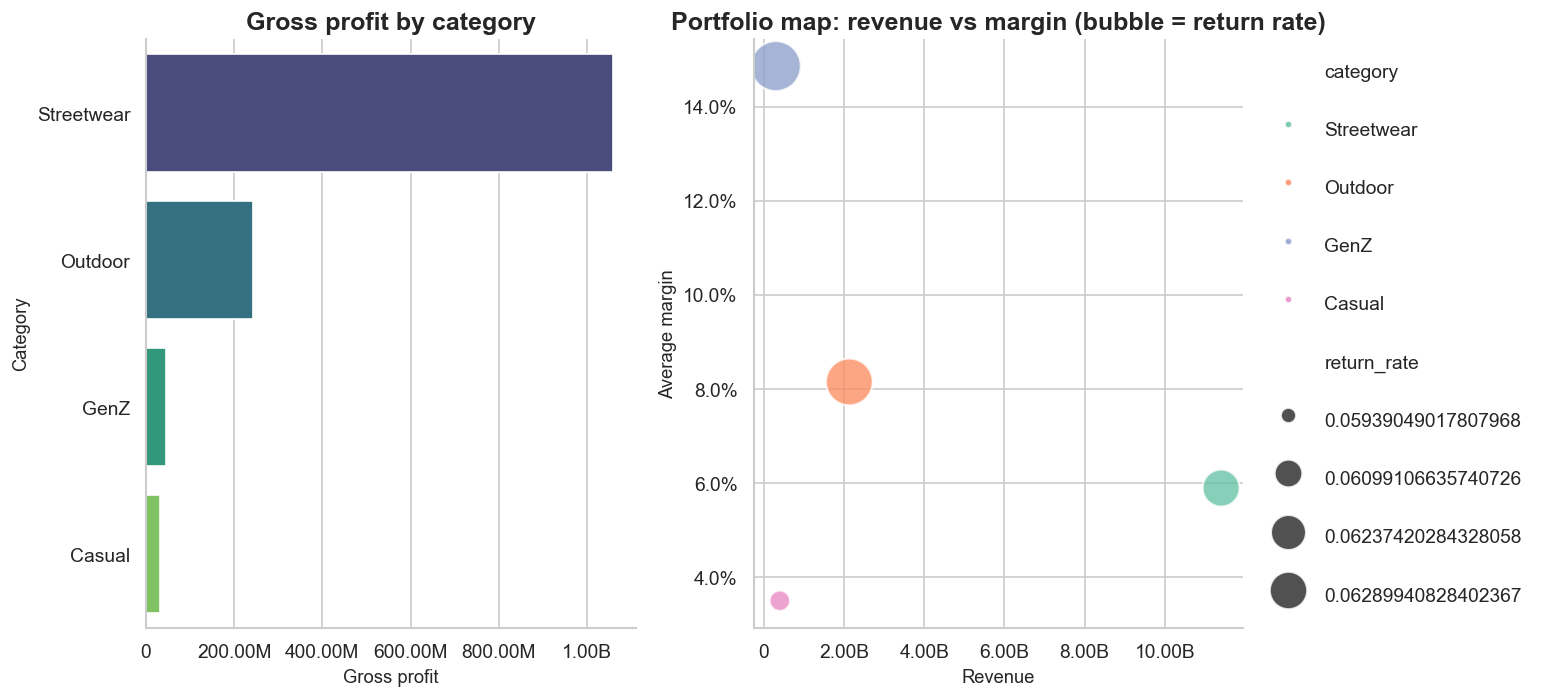

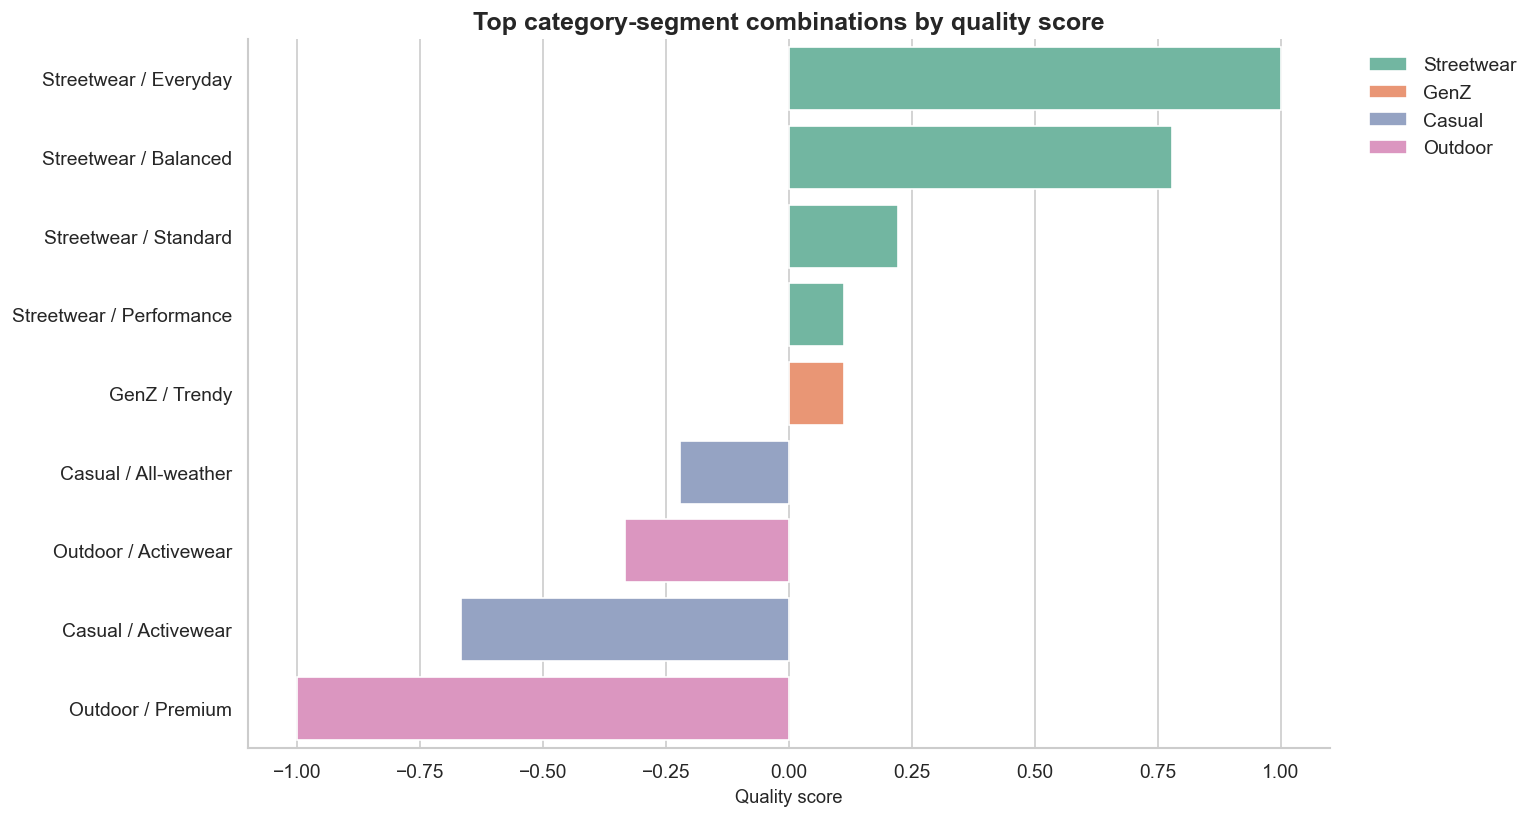

### Insight 2 - Category tốt nhất không chỉ là category doanh thu cao nhất

- Category đóng góp gross profit cao nhất là **Streetwear**, đạt **1.06B** và chiếm **76.8%** profit.
- Category margin cao nhất là **GenZ** với margin **14.9%**.
- Category return rate cao nhất là **GenZ** với **6.3%** dòng có trả hàng.
- Segment có quality score tốt nhất là **Streetwear / Everyday**.

**Business implication / action:** Ưu tiên marketing cho nhóm profit cao + margin tốt + return thấp; audit nhóm doanh thu lớn nhưng return hoặc discount cao.

,category,revenue,gross_profit,units,orders,avg_margin,return_rate,avg_discount_rate,avg_rating,profit_share,revenue_share
3,Streetwear,11.40B,1.06B,"1,606,351","353,786",5.89%,6.10%,4.81%,3.94,76.78%,80.11%
2,Outdoor,2.13B,242.97M,"1,061,333","181,919",8.15%,6.24%,6.75%,3.93,17.64%,14.98%
1,GenZ,299.25M,46.11M,"151,762","33,704",14.86%,6.29%,4.94%,3.92,3.35%,2.10%
0,Casual,399.32M,30.88M,"97,584","21,428",3.50%,5.94%,4.98%,3.92,2.24%,2.81%


In [5]:
cat_perf = commercial_df.groupby("category", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    units=("quantity", "sum"),
    orders=("order_id", "nunique"),
    avg_margin=("gross_margin_rate", "mean"),
    return_rate=("return_flag", "mean"),
    avg_discount_rate=("discount_rate", "mean"),
    avg_rating=("avg_rating", "mean"),
)
cat_perf["profit_share"] = safe_divide(cat_perf["gross_profit"], cat_perf["gross_profit"].sum())
cat_perf["revenue_share"] = safe_divide(cat_perf["revenue"], cat_perf["revenue"].sum())
cat_perf = cat_perf.sort_values("gross_profit", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=cat_perf, y="category", x="gross_profit", ax=axes[0], palette="viridis")
axes[0].set_title("Gross profit by category")
axes[0].set_xlabel("Gross profit")
axes[0].set_ylabel("Category")
format_money_axis(axes[0], axis="x")

sns.scatterplot(
    data=cat_perf,
    x="revenue",
    y="avg_margin",
    size="return_rate",
    hue="category",
    sizes=(150, 900),
    alpha=0.78,
    ax=axes[1],
)
axes[1].set_title("Portfolio map: revenue vs margin (bubble = return rate)")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Average margin")
format_money_axis(axes[1], axis="x")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
style_bubble_legend(axes[1])
plt.tight_layout(rect=[0, 0, 0.82, 1])
savefig("part2_03_product_portfolio.png")
plt.show()

seg_perf = commercial_df.groupby(["category", "segment"], as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    units=("quantity", "sum"),
    avg_margin=("gross_margin_rate", "mean"),
    return_rate=("return_flag", "mean"),
    avg_discount_rate=("discount_rate", "mean"),
)
seg_perf["quality_score"] = (
    seg_perf["gross_profit"].rank(pct=True)
    + seg_perf["avg_margin"].rank(pct=True)
    - seg_perf["return_rate"].rank(pct=True)
    - seg_perf["avg_discount_rate"].rank(pct=True)
)
top_segments = seg_perf.sort_values("quality_score", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(13, 7))
plot_seg = top_segments.assign(label=top_segments["category"] + " / " + top_segments["segment"])
sns.barplot(data=plot_seg, y="label", x="quality_score", hue="category", dodge=False, ax=ax)
ax.set_title("Top category-segment combinations by quality score")
ax.set_xlabel("Quality score")
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
savefig("part2_04_top_segments_quality.png")
plt.show()

top_profit_cat = cat_perf.iloc[0]
top_margin_cat = cat_perf.loc[cat_perf["avg_margin"].idxmax()]
top_return_cat = cat_perf.loc[cat_perf["return_rate"].idxmax()]
best_segment = top_segments.iloc[0]

display_insight(
    "Insight 2 - Category tốt nhất không chỉ là category doanh thu cao nhất",
    [
        f"Category đóng góp gross profit cao nhất là **{top_profit_cat['category']}**, đạt **{money(top_profit_cat['gross_profit'])}** và chiếm **{pct(top_profit_cat['profit_share'])}** profit.",
        f"Category margin cao nhất là **{top_margin_cat['category']}** với margin **{pct(top_margin_cat['avg_margin'])}**.",
        f"Category return rate cao nhất là **{top_return_cat['category']}** với **{pct(top_return_cat['return_rate'])}** dòng có trả hàng.",
        f"Segment có quality score tốt nhất là **{best_segment['category']} / {best_segment['segment']}**.",
    ],
    "Ưu tiên marketing cho nhóm profit cao + margin tốt + return thấp; audit nhóm doanh thu lớn nhưng return hoặc discount cao.",
)
display_table(cat_perf, money_cols=["revenue", "gross_profit"], int_cols=["units", "orders"], pct_cols=["avg_margin", "return_rate", "avg_discount_rate", "profit_share", "revenue_share"], float_cols={"avg_rating": 2})


## 5. Insight 3 - Promotion effectiveness

**Business question:** Khuyến mãi đang tạo tăng trưởng có lợi nhuận hay chỉ mua doanh thu bằng discount?


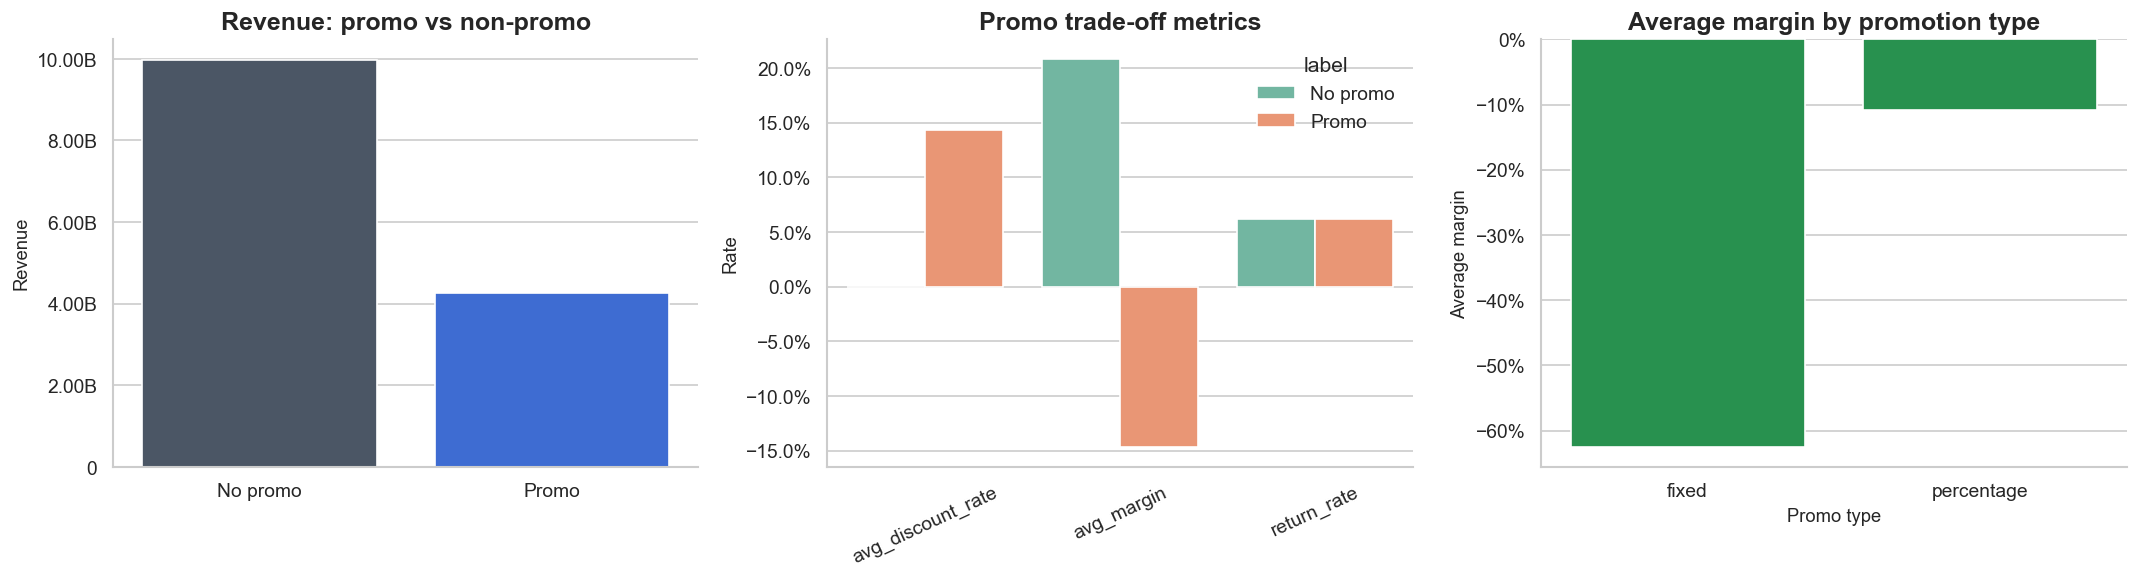

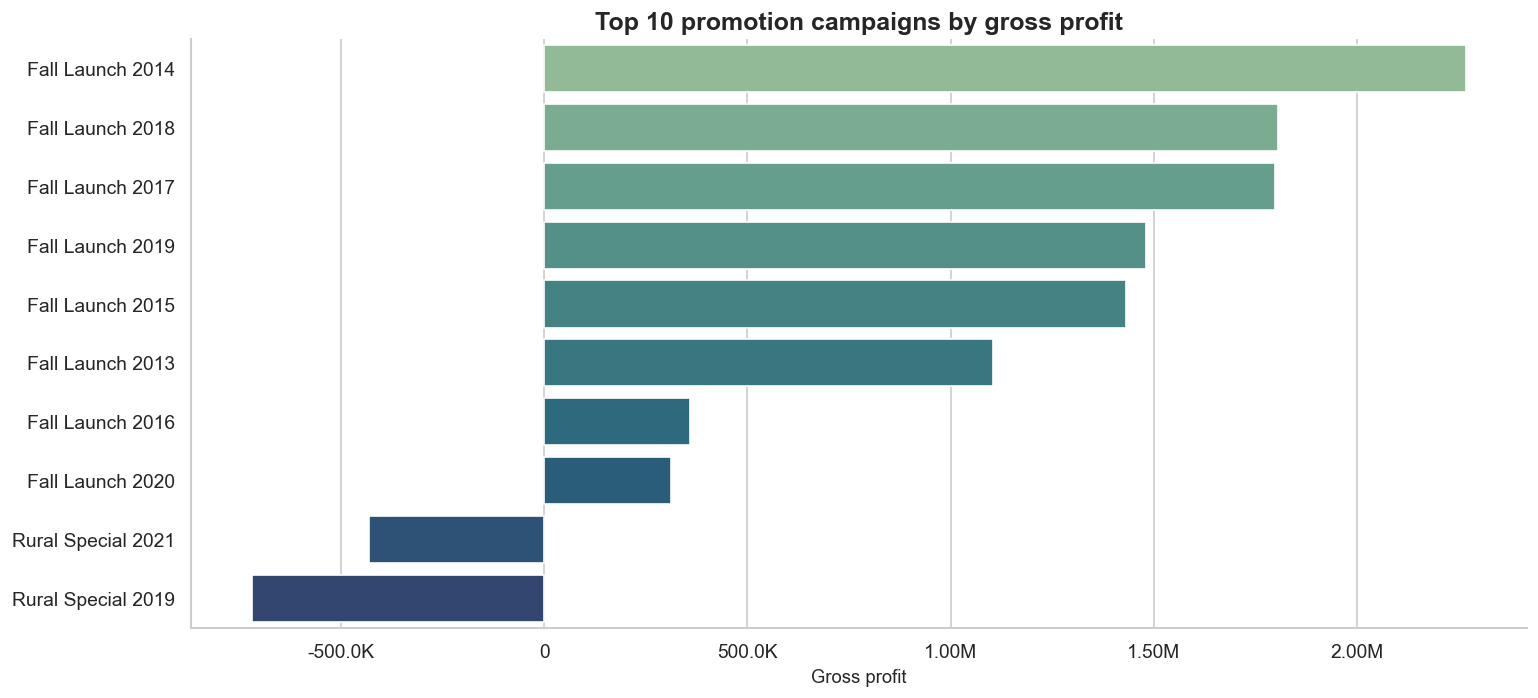

### Insight 3 - Promo phải được chấm bằng profit và return, không chỉ revenue

- Dòng có promo chiếm **38.7%** item lines và **29.9%** revenue.
- Average discount rate của promo lines là **14.3%**, non-promo là **0.0%**.
- Margin gap promo - non-promo là **-35.5%** điểm; return gap là **-0.0%** điểm.
- Campaign gross profit cao nhất là **Fall Launch 2014**, đạt **2.27M**.

**Business implication / action:** Duy trì campaign có profit tốt, discount hợp lý và return không tăng; tránh discount đại trà nếu margin gap âm.

,has_promo,rows,orders,revenue,gross_profit,avg_line_revenue,avg_discount_rate,avg_margin,return_rate,revenue_share,profit_share
0,False,"398,143","362,364",9.98B,1.99B,25.1K,0.00%,20.84%,6.15%,70.11%,144.62%
1,True,"250,853","225,359",4.25B,-614.74M,17.0K,14.31%,-14.70%,6.15%,29.89%,-44.62%


In [6]:
promo_perf = commercial_df.groupby("has_promo", as_index=False).agg(
    rows=("order_id", "count"),
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_line_revenue=("net_revenue", "mean"),
    avg_discount_rate=("discount_rate", "mean"),
    avg_margin=("gross_margin_rate", "mean"),
    return_rate=("return_flag", "mean"),
)
promo_perf["label"] = promo_perf["has_promo"].map({False: "No promo", True: "Promo"})
promo_perf["revenue_share"] = safe_divide(promo_perf["revenue"], promo_perf["revenue"].sum())
promo_perf["profit_share"] = safe_divide(promo_perf["gross_profit"], promo_perf["gross_profit"].sum())

promo_detail = commercial_df.merge(
    promotions[["promo_id", "promo_name", "promo_type", "discount_value", "applicable_category", "promo_channel", "min_order_value"]],
    on="promo_id",
    how="left",
)

promo_type_perf = promo_detail[promo_detail["has_promo"]].groupby("promo_type", as_index=False).agg(
    rows=("order_id", "count"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_rate=("discount_rate", "mean"),
    avg_margin=("gross_margin_rate", "mean"),
    return_rate=("return_flag", "mean"),
)

campaign_perf = promo_detail[promo_detail["has_promo"]].groupby("promo_name", as_index=False).agg(
    rows=("order_id", "count"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_rate=("discount_rate", "mean"),
    avg_margin=("gross_margin_rate", "mean"),
    return_rate=("return_flag", "mean"),
).sort_values("gross_profit", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=promo_perf, x="label", y="revenue", ax=axes[0], palette=[COLOR_GRAY, COLOR_MAIN])
axes[0].set_title("Revenue: promo vs non-promo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue")
format_money_axis(axes[0])

promo_melt = promo_perf.melt(
    id_vars=["label"],
    value_vars=["avg_discount_rate", "avg_margin", "return_rate"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=promo_melt, x="metric", y="value", hue="label", ax=axes[1])
axes[1].set_title("Promo trade-off metrics")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rate")
axes[1].tick_params(axis="x", rotation=25)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))

sns.barplot(data=promo_type_perf, x="promo_type", y="avg_margin", ax=axes[2], color=COLOR_GREEN)
axes[2].set_title("Average margin by promotion type")
axes[2].set_xlabel("Promo type")
axes[2].set_ylabel("Average margin")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout()
savefig("part2_05_promotion_tradeoffs.png")
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=campaign_perf, y="promo_name", x="gross_profit", ax=ax, palette="crest")
ax.set_title("Top 10 promotion campaigns by gross profit")
ax.set_xlabel("Gross profit")
ax.set_ylabel("")
format_money_axis(ax, axis="x")
plt.tight_layout()
savefig("part2_06_top_promo_campaigns.png")
plt.show()

promo_yes = promo_perf[promo_perf["has_promo"]].iloc[0]
promo_no = promo_perf[~promo_perf["has_promo"]].iloc[0]
margin_gap = promo_yes["avg_margin"] - promo_no["avg_margin"]
return_gap = promo_yes["return_rate"] - promo_no["return_rate"]

display_insight(
    "Insight 3 - Promo phải được chấm bằng profit và return, không chỉ revenue",
    [
        f"Dòng có promo chiếm **{pct(promo_yes['rows'] / promo_perf['rows'].sum())}** item lines và **{pct(promo_yes['revenue_share'])}** revenue.",
        f"Average discount rate của promo lines là **{pct(promo_yes['avg_discount_rate'])}**, non-promo là **{pct(promo_no['avg_discount_rate'])}**.",
        f"Margin gap promo - non-promo là **{pct(margin_gap)}** điểm; return gap là **{pct(return_gap)}** điểm.",
        f"Campaign gross profit cao nhất là **{campaign_perf.iloc[0]['promo_name']}**, đạt **{money(campaign_perf.iloc[0]['gross_profit'])}**.",
    ],
    "Duy trì campaign có profit tốt, discount hợp lý và return không tăng; tránh discount đại trà nếu margin gap âm.",
)
display_table(promo_perf.drop(columns=["label"]), money_cols=["revenue", "gross_profit", "avg_line_revenue"], int_cols=["rows", "orders"], pct_cols=["avg_discount_rate", "avg_margin", "return_rate", "revenue_share", "profit_share"])


## 6. Insight 4 - Customer retention và nhóm khách hàng

**Business question:** Khách hàng quay lại mua nhanh hay chậm, và nhóm khách hàng nào đáng ưu tiên hơn cho CRM/acquisition?


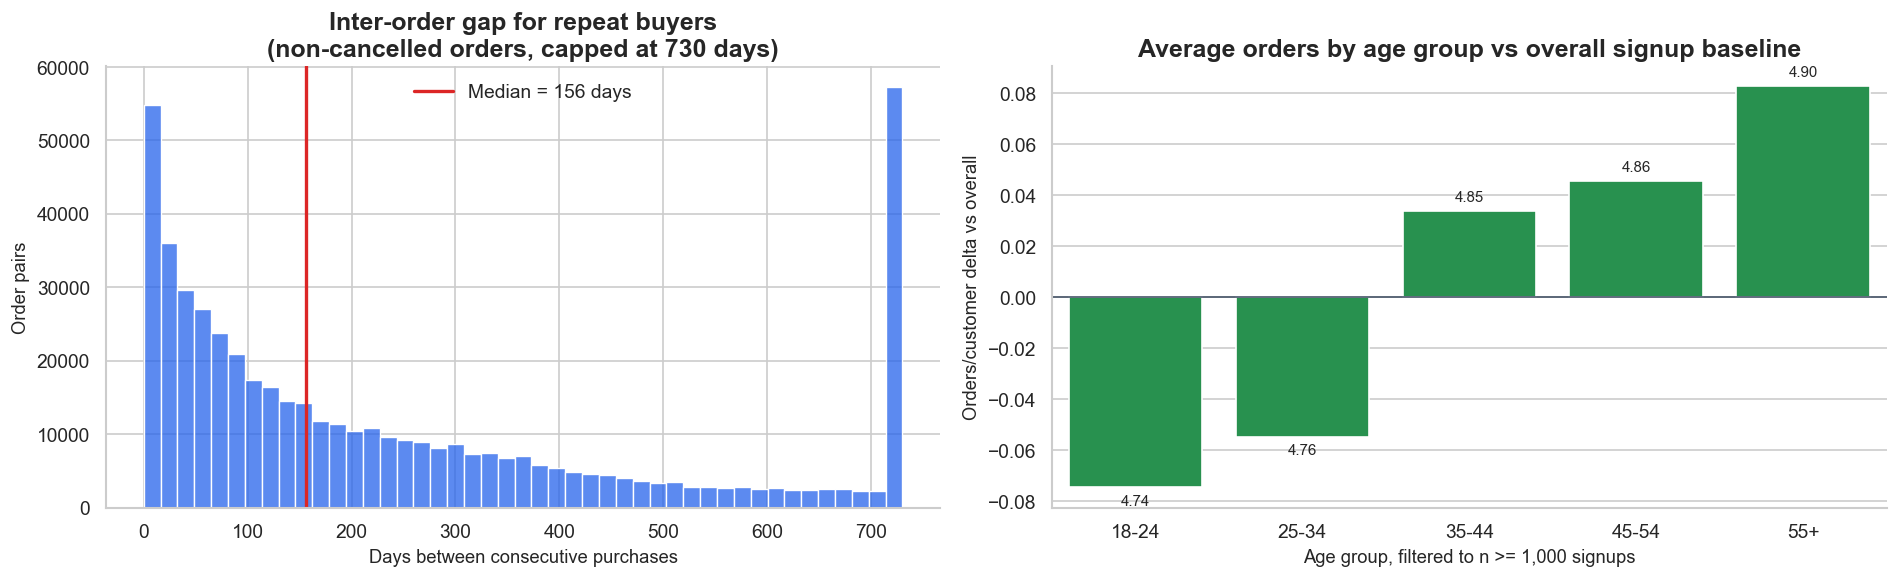

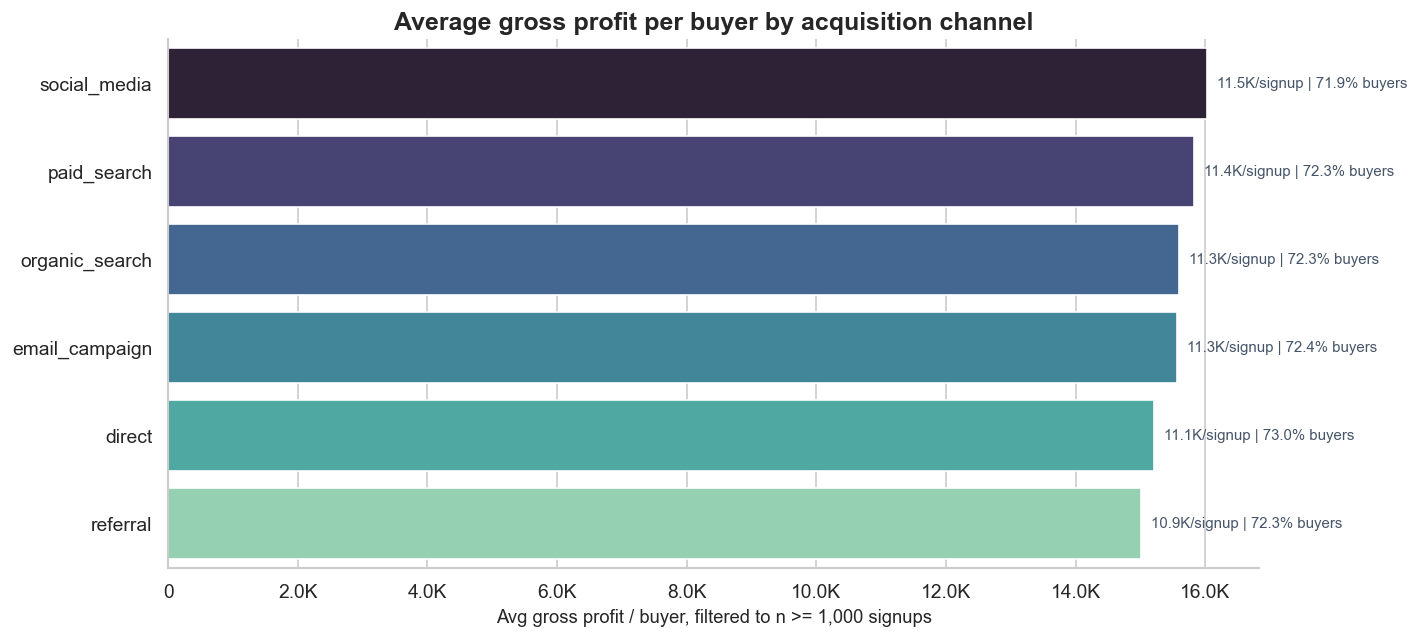

### Insight 4 - Retention window có thể biến thành CRM trigger

- Median inter-order gap của khách mua lặp lại, chỉ tính đơn không cancelled, là **156 ngày**.
- Tỷ lệ signup có hơn một đơn không cancelled là **53.7%**.
- Sau filter n >= 1,000 signups, age group vượt baseline order/customer cao nhất là **55+**: **4.90 đơn/signup**, cao hơn baseline **0.08**.
- Acquisition channel có gross profit per buyer cao nhất là **social_media** với **16.0K**; per signup là **11.5K**.

**Business implication / action:** Dùng repeat-gap để đặt CRM trigger; khi so sánh segment, luôn đọc cùng filter mẫu, baseline orders/signup, buyer rate và gross profit per buyer.

,age_group,customers,buyers,avg_orders,repeat_rate,avg_orders_per_buyer,avg_revenue_per_buyer,avg_profit_per_buyer,buyer_rate,avg_orders_delta
0,18-24,"17,039","12,295",4.74,53.43%,6.57,158.8K,15.3K,72.16%,-0.07
1,25-34,"36,342","26,167",4.76,53.47%,6.62,160.7K,15.6K,72.00%,-0.05
2,35-44,"31,920","23,091",4.85,53.78%,6.71,162.3K,15.6K,72.34%,0.03
3,45-54,"23,172","16,801",4.86,53.77%,6.71,163.1K,16.0K,72.51%,0.05
4,55+,"13,457","9,769",4.90,54.19%,6.75,162.7K,15.5K,72.59%,0.08


,acquisition_channel,customers,buyers,avg_orders,avg_profit_per_signup,avg_profit_per_buyer,median_profit_per_buyer,buyer_rate
5,social_media,"24,448","17,575",4.81,11.5K,16.0K,7.2K,71.89%
3,paid_search,"24,285","17,557",4.82,11.4K,15.8K,7.0K,72.30%
2,organic_search,"36,450","26,341",4.84,11.3K,15.6K,6.9K,72.27%
1,email_campaign,"14,674","10,620",4.81,11.3K,15.6K,6.6K,72.37%
0,direct,"9,803","7,154",4.83,11.1K,15.2K,6.8K,72.98%
4,referral,"12,270","8,876",4.77,10.9K,15.0K,6.5K,72.34%


In [7]:
valid_orders = orders.loc[~orders["order_status"].eq("cancelled")].copy()
orders_sorted = valid_orders.sort_values(["customer_id", "order_date"]).copy()
orders_sorted["previous_order_date"] = orders_sorted.groupby("customer_id")["order_date"].shift()
orders_sorted["inter_order_gap"] = (orders_sorted["order_date"] - orders_sorted["previous_order_date"]).dt.days
repeat_gaps = orders_sorted["inter_order_gap"].dropna()

customer_orders = valid_orders.groupby("customer_id", as_index=False).agg(
    order_count=("order_id", "nunique"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
)
customer_value = commercial_df.groupby("customer_id", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    units=("quantity", "sum"),
)
customer_profile = (
    customers
    .merge(customer_orders, on="customer_id", how="left")
    .merge(customer_value, on="customer_id", how="left")
)
for col in ["order_count", "revenue", "gross_profit", "units"]:
    customer_profile[col] = customer_profile[col].fillna(0)
customer_profile["is_buyer"] = customer_profile["order_count"] > 0
customer_profile["is_repeat_buyer"] = customer_profile["order_count"] > 1
active_customer_profile = customer_profile.loc[customer_profile["is_buyer"]].copy()

MIN_CUSTOMERS = 1_000
age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]
overall_avg_orders = customer_profile["order_count"].mean()

age_signup = customer_profile[customer_profile["age_group"].notna()].groupby("age_group", as_index=False).agg(
    customers=("customer_id", "nunique"),
    buyers=("is_buyer", "sum"),
    avg_orders=("order_count", "mean"),
    repeat_rate=("is_repeat_buyer", "mean"),
)
age_buyer = active_customer_profile[active_customer_profile["age_group"].notna()].groupby("age_group", as_index=False).agg(
    avg_orders_per_buyer=("order_count", "mean"),
    avg_revenue_per_buyer=("revenue", "mean"),
    avg_profit_per_buyer=("gross_profit", "mean"),
)
age_perf = age_signup.merge(age_buyer, on="age_group", how="left")
age_perf["buyer_rate"] = safe_divide(age_perf["buyers"], age_perf["customers"])
age_perf["avg_orders_delta"] = age_perf["avg_orders"] - overall_avg_orders
age_perf["age_group"] = pd.Categorical(age_perf["age_group"], categories=age_order, ordered=True)
age_perf = age_perf.loc[age_perf["customers"] >= MIN_CUSTOMERS].sort_values("age_group")

acq_signup = customer_profile[customer_profile["acquisition_channel"].notna()].groupby("acquisition_channel", as_index=False).agg(
    customers=("customer_id", "nunique"),
    buyers=("is_buyer", "sum"),
    avg_orders=("order_count", "mean"),
    avg_profit_per_signup=("gross_profit", "mean"),
)
acq_buyer = active_customer_profile[active_customer_profile["acquisition_channel"].notna()].groupby("acquisition_channel", as_index=False).agg(
    avg_profit_per_buyer=("gross_profit", "mean"),
    median_profit_per_buyer=("gross_profit", "median"),
)
acq_perf = acq_signup.merge(acq_buyer, on="acquisition_channel", how="left")
acq_perf["buyer_rate"] = safe_divide(acq_perf["buyers"], acq_perf["customers"])
acq_perf = acq_perf.loc[acq_perf["customers"] >= MIN_CUSTOMERS].sort_values("avg_profit_per_buyer", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(repeat_gaps.clip(upper=730), bins=45, color=COLOR_MAIN, ax=axes[0])
axes[0].axvline(repeat_gaps.median(), color=COLOR_RED, linewidth=2, label=f"Median = {repeat_gaps.median():.0f} days")
axes[0].set_title("Inter-order gap for repeat buyers\n(non-cancelled orders, capped at 730 days)")
axes[0].set_xlabel("Days between consecutive purchases")
axes[0].set_ylabel("Order pairs")
axes[0].legend()

sns.barplot(data=age_perf, x="age_group", y="avg_orders_delta", ax=axes[1], color=COLOR_GREEN)
axes[1].axhline(0, color=COLOR_GRAY, linewidth=1)
axes[1].set_title("Average orders by age group vs overall signup baseline")
axes[1].set_xlabel(f"Age group, filtered to n >= {MIN_CUSTOMERS:,} signups")
axes[1].set_ylabel("Orders/customer delta vs overall")
for patch, (_, row) in zip(axes[1].patches, age_perf.iterrows()):
    axes[1].annotate(
        f"{row['avg_orders']:.2f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom" if patch.get_height() >= 0 else "top",
        xytext=(0, 4 if patch.get_height() >= 0 else -4),
        textcoords="offset points",
        fontsize=9,
    )
plt.tight_layout()
savefig("part2_07_customer_retention_age.png")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.barplot(data=acq_perf, y="acquisition_channel", x="avg_profit_per_buyer", ax=ax, palette="mako")
ax.set_title("Average gross profit per buyer by acquisition channel")
ax.set_xlabel(f"Avg gross profit / buyer, filtered to n >= {MIN_CUSTOMERS:,} signups")
ax.set_ylabel("")
format_money_axis(ax, axis="x")
for patch, (_, row) in zip(ax.patches, acq_perf.iterrows()):
    ax.annotate(
        f"{money(row['avg_profit_per_signup'])}/signup | {pct(row['buyer_rate'])} buyers",
        (patch.get_width(), patch.get_y() + patch.get_height() / 2),
        ha="left",
        va="center",
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=9,
        color=COLOR_GRAY,
    )
plt.tight_layout()
savefig("part2_08_acquisition_profit.png")
plt.show()

best_age = age_perf.loc[age_perf["avg_orders_delta"].idxmax()]
best_acq = acq_perf.iloc[0]
repeat_customer_rate = customer_profile["is_repeat_buyer"].mean()

display_insight(
    "Insight 4 - Retention window có thể biến thành CRM trigger",
    [
        f"Median inter-order gap của khách mua lặp lại, chỉ tính đơn không cancelled, là **{repeat_gaps.median():.0f} ngày**.",
        f"Tỷ lệ signup có hơn một đơn không cancelled là **{pct(repeat_customer_rate)}**.",
        f"Sau filter n >= {MIN_CUSTOMERS:,} signups, age group vượt baseline order/customer cao nhất là **{best_age['age_group']}**: **{best_age['avg_orders']:.2f} đơn/signup**, cao hơn baseline **{best_age['avg_orders_delta']:.2f}**.",
        f"Acquisition channel có gross profit per buyer cao nhất là **{best_acq['acquisition_channel']}** với **{money(best_acq['avg_profit_per_buyer'])}**; per signup là **{money(best_acq['avg_profit_per_signup'])}**.",
    ],
    "Dùng repeat-gap để đặt CRM trigger; khi so sánh segment, luôn đọc cùng filter mẫu, baseline orders/signup, buyer rate và gross profit per buyer.",
)
display_table(
    age_perf,
    money_cols=["avg_revenue_per_buyer", "avg_profit_per_buyer"],
    int_cols=["customers", "buyers"],
    pct_cols=["buyer_rate", "repeat_rate"],
    float_cols={"avg_orders": 2, "avg_orders_delta": 2, "avg_orders_per_buyer": 2},
)
display_table(
    acq_perf,
    money_cols=["avg_profit_per_signup", "avg_profit_per_buyer", "median_profit_per_buyer"],
    int_cols=["customers", "buyers"],
    pct_cols=["buyer_rate"],
    float_cols={"avg_orders": 2},
)


## 7. Insight 5 - Returns, delivery và customer experience

**Business question:** Doanh nghiệp đang mất lợi nhuận sau bán hàng vì sản phẩm, size hay logistics?


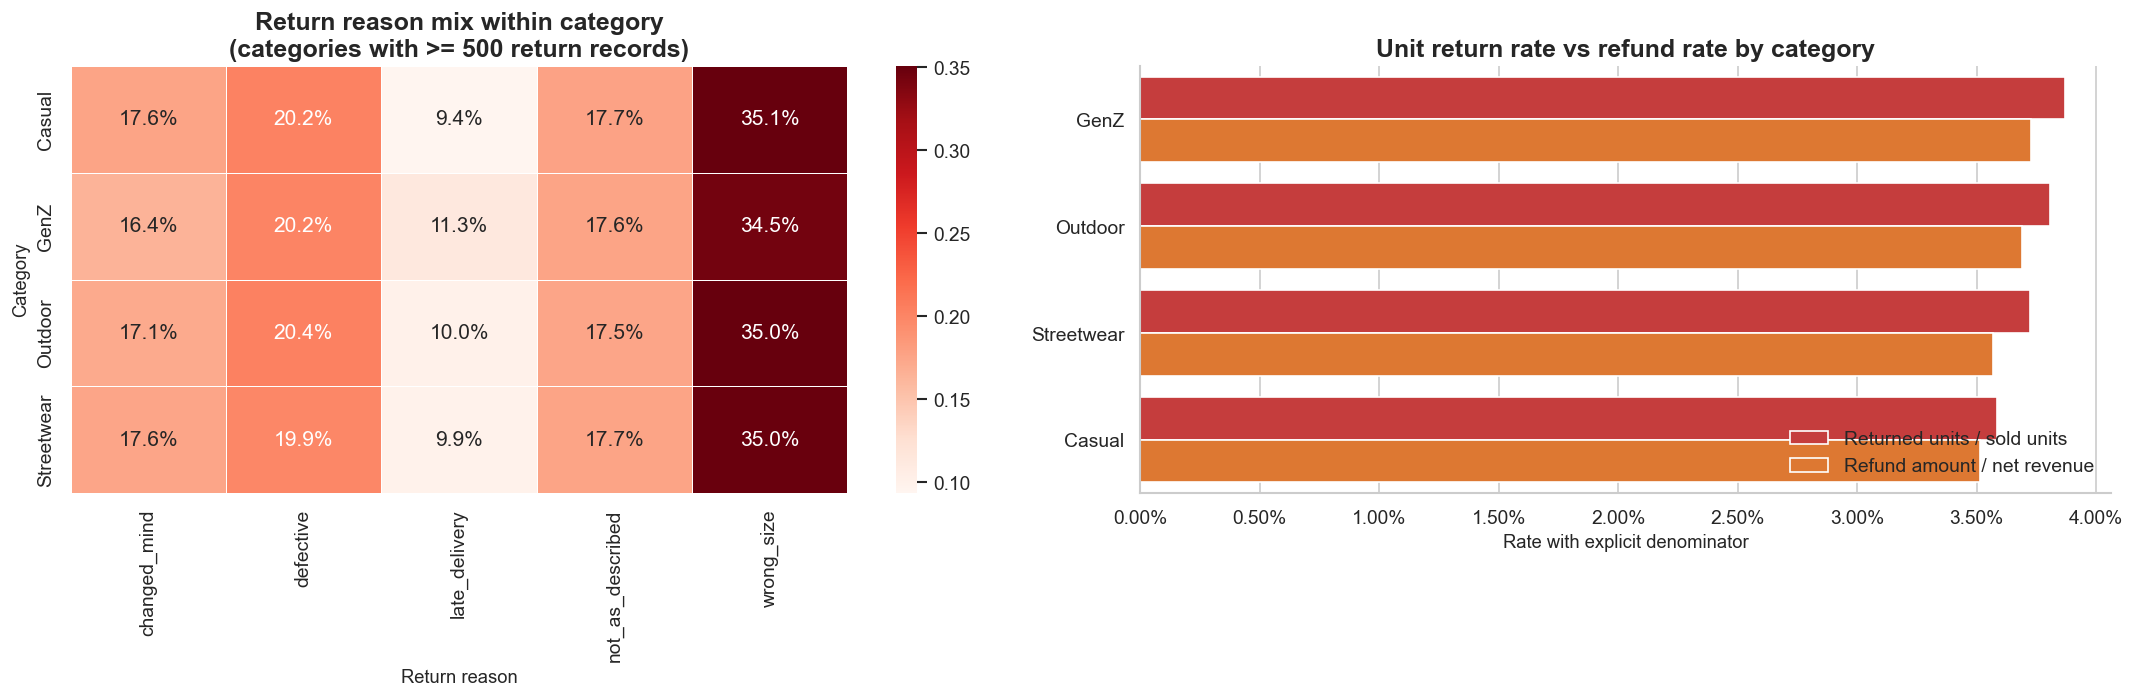

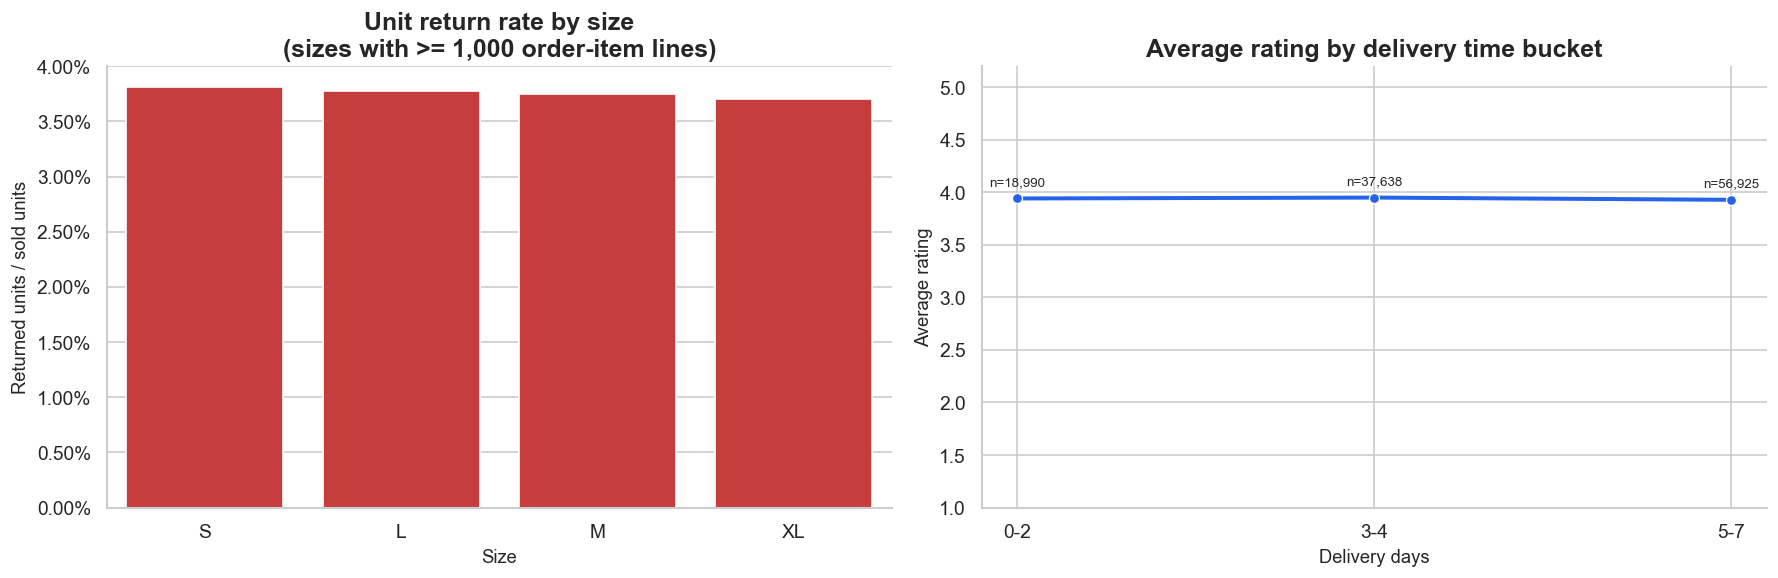

### Insight 5 - Returns cần xử lý theo nguyên nhân, không xử lý bằng một chính sách chung

- Lý do trả hàng phổ biến nhất là **wrong_size**: **13,967 records**, chiếm **35.0%** return records.
- Category có unit return rate cao nhất là **GenZ** với **3.9%** returned units / sold units.
- Category có refund/revenue cao nhất là **GenZ** với **3.7%**.
- Sau filter size có >= 1,000 lines, size có unit return rate cao nhất là **S** với **3.8%**.

**Business implication / action:** Nếu lý do là wrong_size: cải thiện size guide. Nếu late_delivery: kiểm tra carrier/vùng giao hàng. Nếu defective: rà soát QC/supplier. Ưu tiên theo refund/revenue để xử lý nơi mất tiền nhiều nhất.

,return_reason,return_records,units_returned,refund_amount,record_share,unit_share
4,wrong_size,"13,967","38,042",176.69M,34.97%,34.71%
1,defective,"8,020","22,274",103.60M,20.08%,20.33%
3,not_as_described,"7,035","19,358",90.65M,17.61%,17.66%
0,changed_mind,"6,931","19,144",89.72M,17.35%,17.47%
2,late_delivery,"3,986","10,768",49.94M,9.98%,9.83%


,category,item_lines,units_sold,units_returned,return_lines,refund_amount,revenue,avg_delivery_days,avg_rating,returned_line_rate,unit_return_rate,refund_rate
1,GenZ,"33,800","151,762","5,873","2,126",11.15M,299.25M,4.50,3.92,6.29%,3.87%,3.73%
2,Outdoor,"235,995","1,061,333","40,417","14,720",78.72M,2.13B,4.50,3.93,6.24%,3.81%,3.69%
3,Streetwear,"357,413","1,606,351","59,812","21,799",406.77M,11.40B,4.50,3.94,6.10%,3.72%,3.57%
0,Casual,"21,788","97,584","3,499","1,294",14.03M,399.32M,4.49,3.92,5.94%,3.59%,3.51%


In [8]:
MIN_RETURN_RECORDS = 500
MIN_SIZE_LINES = 1_000

return_reason = returns.merge(products[["product_id", "category", "segment", "size"]], on="product_id", how="left")
reason_counts = pd.crosstab(return_reason["category"], return_reason["return_reason"])
eligible_return_categories = reason_counts.sum(axis=1).loc[lambda s: s >= MIN_RETURN_RECORDS].index
reason_mix_pct = (
    reason_counts
    .loc[eligible_return_categories]
    .div(reason_counts.loc[eligible_return_categories].sum(axis=1), axis=0)
    .sort_index()
)

reason_summary = return_reason.groupby("return_reason", as_index=False).agg(
    return_records=("return_id", "count"),
    units_returned=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum"),
)
reason_summary["record_share"] = safe_divide(reason_summary["return_records"], reason_summary["return_records"].sum())
reason_summary["unit_share"] = safe_divide(reason_summary["units_returned"], reason_summary["units_returned"].sum())
reason_summary = reason_summary.sort_values("return_records", ascending=False)

return_cat = commercial_df.groupby("category", as_index=False).agg(
    item_lines=("order_id", "count"),
    units_sold=("quantity", "sum"),
    units_returned=("returned_qty", "sum"),
    return_lines=("return_flag", "sum"),
    refund_amount=("refund_amount", "sum"),
    revenue=("net_revenue", "sum"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_rating=("avg_rating", "mean"),
)
return_cat["returned_line_rate"] = safe_divide(return_cat["return_lines"], return_cat["item_lines"])
return_cat["unit_return_rate"] = safe_divide(return_cat["units_returned"], return_cat["units_sold"])
return_cat["refund_rate"] = safe_divide(return_cat["refund_amount"], return_cat["revenue"])
return_cat = return_cat.sort_values("unit_return_rate", ascending=False)

return_rate_long = return_cat.melt(
    id_vars=["category"],
    value_vars=["unit_return_rate", "refund_rate"],
    var_name="metric",
    value_name="rate",
)
return_rate_long["metric"] = return_rate_long["metric"].map({
    "unit_return_rate": "Returned units / sold units",
    "refund_rate": "Refund amount / net revenue",
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(reason_mix_pct, annot=True, fmt=".1%", cmap="Reds", linewidths=0.5, ax=axes[0])
axes[0].set_title(f"Return reason mix within category\n(categories with >= {MIN_RETURN_RECORDS:,} return records)")
axes[0].set_xlabel("Return reason")
axes[0].set_ylabel("Category")

sns.barplot(data=return_rate_long, y="category", x="rate", hue="metric", ax=axes[1], palette=[COLOR_RED, COLOR_ORANGE])
axes[1].set_title("Unit return rate vs refund rate by category")
axes[1].set_xlabel("Rate with explicit denominator")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].legend(loc="lower right")
plt.tight_layout()
savefig("part2_09_returns_delivery.png")
plt.show()

size_lines = commercial_df.groupby("size", as_index=False).agg(
    order_item_lines=("order_id", "count"),
    units_sold=("quantity", "sum"),
)
size_returns = return_reason.groupby("size", as_index=False).agg(
    return_records=("return_id", "count"),
    units_returned=("return_quantity", "sum"),
)
size_summary = size_lines.merge(size_returns, on="size", how="left").fillna(0)
size_summary["record_return_rate"] = safe_divide(size_summary["return_records"], size_summary["order_item_lines"])
size_summary["unit_return_rate"] = safe_divide(size_summary["units_returned"], size_summary["units_sold"])
size_summary = size_summary.loc[size_summary["order_item_lines"] >= MIN_SIZE_LINES].sort_values("unit_return_rate", ascending=False)

rating_by_delivery = commercial_df.dropna(subset=["delivery_days", "avg_rating"]).copy()
rating_by_delivery["delivery_bucket"] = pd.cut(
    rating_by_delivery["delivery_days"],
    bins=[-1, 2, 4, 7, 14, 60],
    labels=["0-2", "3-4", "5-7", "8-14", "15+"],
)
rating_bucket = rating_by_delivery.groupby("delivery_bucket", as_index=False).agg(
    avg_rating=("avg_rating", "mean"),
    rows=("order_id", "count"),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=size_summary, x="size", y="unit_return_rate", color=COLOR_RED, ax=axes[0])
axes[0].set_title(f"Unit return rate by size\n(sizes with >= {MIN_SIZE_LINES:,} order-item lines)")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Returned units / sold units")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))

sns.lineplot(data=rating_bucket, x="delivery_bucket", y="avg_rating", marker="o", linewidth=2.4, color=COLOR_MAIN, ax=axes[1])
axes[1].set_title("Average rating by delivery time bucket")
axes[1].set_xlabel("Delivery days")
axes[1].set_ylabel("Average rating")
axes[1].set_ylim(1, 5.2)
for _, row in rating_bucket.iterrows():
    axes[1].annotate(f"n={row['rows']:,.0f}", (row["delivery_bucket"], row["avg_rating"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
savefig("part2_10_size_rating_delivery.png")
plt.show()

top_reason = reason_summary.iloc[0]
top_return_cat = return_cat.iloc[0]
worst_refund_cat = return_cat.loc[return_cat["refund_rate"].idxmax()]
worst_size = size_summary.iloc[0]

display_insight(
    "Insight 5 - Returns cần xử lý theo nguyên nhân, không xử lý bằng một chính sách chung",
    [
        f"Lý do trả hàng phổ biến nhất là **{top_reason['return_reason']}**: **{top_reason['return_records']:,.0f} records**, chiếm **{pct(top_reason['record_share'])}** return records.",
        f"Category có unit return rate cao nhất là **{top_return_cat['category']}** với **{pct(top_return_cat['unit_return_rate'])}** returned units / sold units.",
        f"Category có refund/revenue cao nhất là **{worst_refund_cat['category']}** với **{pct(worst_refund_cat['refund_rate'])}**.",
        f"Sau filter size có >= {MIN_SIZE_LINES:,} lines, size có unit return rate cao nhất là **{worst_size['size']}** với **{pct(worst_size['unit_return_rate'])}**.",
    ],
    "Nếu lý do là wrong_size: cải thiện size guide. Nếu late_delivery: kiểm tra carrier/vùng giao hàng. Nếu defective: rà soát QC/supplier. Ưu tiên theo refund/revenue để xử lý nơi mất tiền nhiều nhất.",
)
display_table(reason_summary, money_cols=["refund_amount"], int_cols=["return_records", "units_returned"], pct_cols=["record_share", "unit_share"])
display_table(
    return_cat,
    money_cols=["refund_amount", "revenue"],
    int_cols=["item_lines", "units_sold", "units_returned", "return_lines"],
    pct_cols=["returned_line_rate", "unit_return_rate", "refund_rate"],
    float_cols={"avg_delivery_days": 2, "avg_rating": 2},
)


## 8. Insight 6 - Web traffic quality như demand signal

**Business question:** Nguồn traffic nào có engagement tốt, và traffic có thể dùng làm tín hiệu dẫn cho revenue không?


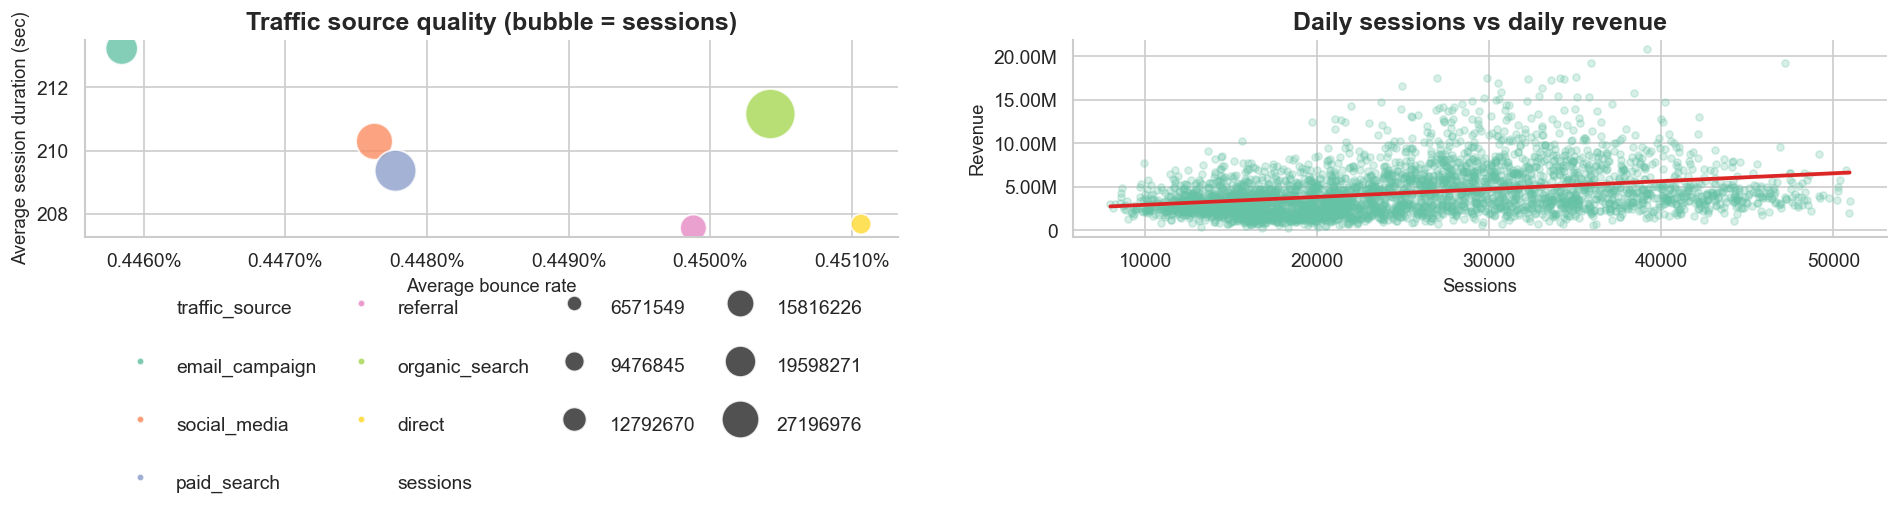

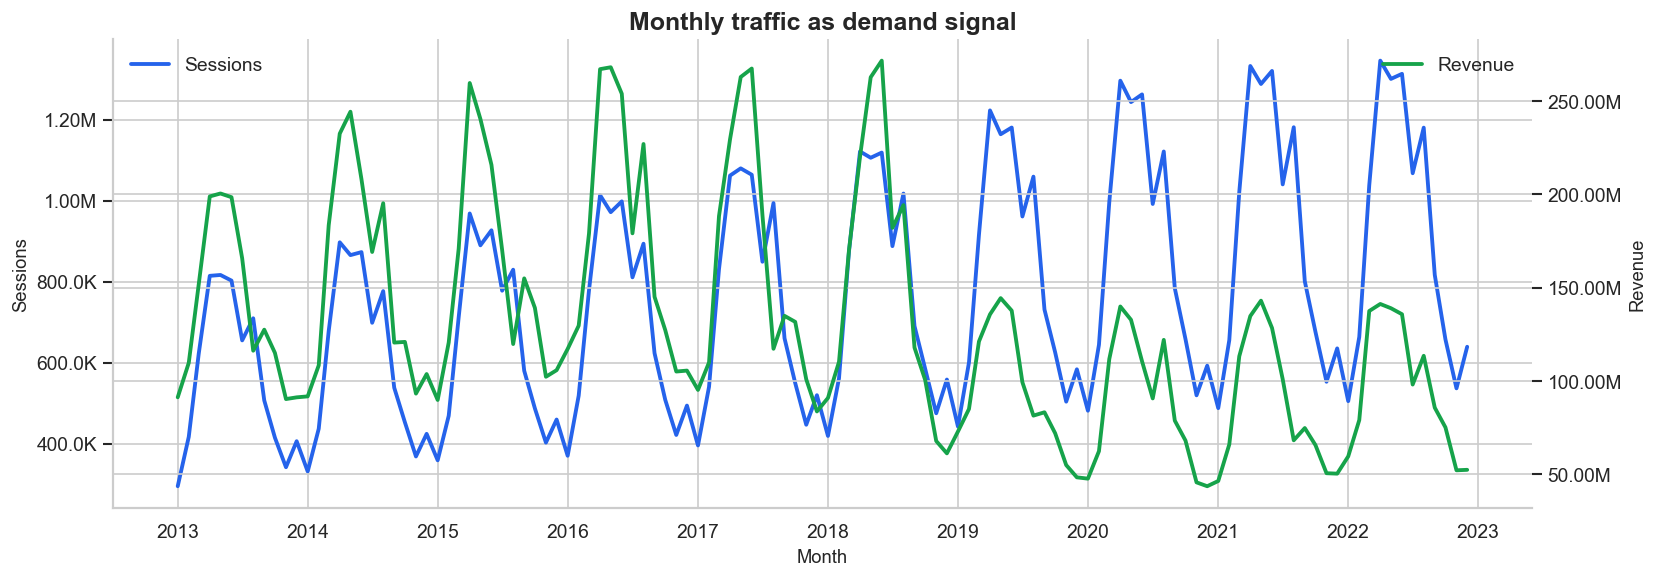

### Insight 6 - Traffic là leading signal, nhưng chất lượng traffic quan trọng hơn volume thô

- Traffic source có bounce thấp nhất là **email_campaign** với **0.45%**.
- Traffic source có session duration cao nhất là **email_campaign** với **213.2 giây**.
- Tương quan daily sessions - daily revenue là **0.321**.
- Tương quan bounce rate - conversion proxy là **-0.028**.

**Business implication / action:** Dùng traffic làm biến sớm cho demand planning, nhưng phân bổ ngân sách theo bounce, duration và conversion proxy thay vì sessions thô.

,traffic_source,days,sessions,page_views,avg_bounce,avg_duration,views_per_session
1,email_campaign,505,"12,792,670","55,477,636",0.45%,213.2,4.34
5,social_media,632,"15,816,226","68,072,140",0.45%,210.3,4.30
3,paid_search,784,"19,598,271","85,079,551",0.45%,209.4,4.34
4,referral,375,"9,476,845","41,655,659",0.45%,207.6,4.40
2,organic_search,"1,090","27,196,976","117,606,452",0.45%,211.2,4.32
0,direct,266,"6,571,549","28,771,362",0.45%,207.7,4.38


In [9]:
daily_orders = orders.groupby("order_date", as_index=False).agg(orders=("order_id", "nunique"))
traffic_daily = web.groupby("date", as_index=False).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean"),
)
traffic_orders = traffic_daily.merge(daily_orders, left_on="date", right_on="order_date", how="left")
traffic_orders["orders"] = traffic_orders["orders"].fillna(0)
traffic_orders["conversion_proxy"] = safe_divide(traffic_orders["orders"], traffic_orders["sessions"])
traffic_orders = traffic_orders.merge(sales2[["Date", "Revenue"]], left_on="date", right_on="Date", how="left")

source_perf = web.groupby("traffic_source", as_index=False).agg(
    days=("date", "count"),
    sessions=("sessions", "sum"),
    page_views=("page_views", "sum"),
    avg_bounce=("bounce_rate", "mean"),
    avg_duration=("avg_session_duration_sec", "mean"),
)
source_perf["views_per_session"] = safe_divide(source_perf["page_views"], source_perf["sessions"])
source_perf = source_perf.sort_values("avg_bounce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=source_perf,
    x="avg_bounce",
    y="avg_duration",
    size="sessions",
    hue="traffic_source",
    sizes=(150, 900),
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title("Traffic source quality (bubble = sessions)")
axes[0].set_xlabel("Average bounce rate")
axes[0].set_ylabel("Average session duration (sec)")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
style_bubble_legend(axes[0], loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=4)

plot_df = traffic_orders.dropna(subset=["Revenue", "sessions", "conversion_proxy"])
sns.regplot(data=plot_df, x="sessions", y="Revenue", scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": COLOR_RED}, ax=axes[1])
axes[1].set_title("Daily sessions vs daily revenue")
axes[1].set_xlabel("Sessions")
axes[1].set_ylabel("Revenue")
format_money_axis(axes[1])
plt.tight_layout(rect=[0, 0.14, 1, 1])
savefig("part2_11_traffic_quality_revenue.png")
plt.show()

traffic_monthly = traffic_orders.copy()
traffic_monthly["month"] = traffic_monthly["date"].dt.to_period("M").dt.to_timestamp()
traffic_monthly = traffic_monthly.groupby("month", as_index=False).agg(
    sessions=("sessions", "sum"),
    revenue=("Revenue", "sum"),
    conversion_proxy=("conversion_proxy", "mean"),
)

fig, ax1 = plt.subplots(figsize=(14, 5))
sns.lineplot(data=traffic_monthly, x="month", y="sessions", ax=ax1, color=COLOR_MAIN, label="Sessions", linewidth=2.3)
ax1.set_title("Monthly traffic as demand signal")
ax1.set_xlabel("Month")
ax1.set_ylabel("Sessions")
format_money_axis(ax1)
ax2 = ax1.twinx()
sns.lineplot(data=traffic_monthly, x="month", y="revenue", ax=ax2, color=COLOR_GREEN, label="Revenue", linewidth=2.3)
ax2.set_ylabel("Revenue")
format_money_axis(ax2)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
savefig("part2_12_monthly_traffic_revenue.png")
plt.show()

best_source = source_perf.iloc[0]
long_source = source_perf.loc[source_perf["avg_duration"].idxmax()]
corr_sessions_revenue = plot_df[["sessions", "Revenue"]].corr().iloc[0, 1]
corr_bounce_conversion = plot_df[["bounce_rate", "conversion_proxy"]].corr().iloc[0, 1]

display_insight(
    "Insight 6 - Traffic là leading signal, nhưng chất lượng traffic quan trọng hơn volume thô",
    [
        f"Traffic source có bounce thấp nhất là **{best_source['traffic_source']}** với **{pct(best_source['avg_bounce'], 2)}**.",
        f"Traffic source có session duration cao nhất là **{long_source['traffic_source']}** với **{long_source['avg_duration']:.1f} giây**.",
        f"Tương quan daily sessions - daily revenue là **{corr_sessions_revenue:.3f}**.",
        f"Tương quan bounce rate - conversion proxy là **{corr_bounce_conversion:.3f}**.",
    ],
    "Dùng traffic làm biến sớm cho demand planning, nhưng phân bổ ngân sách theo bounce, duration và conversion proxy thay vì sessions thô.",
)
display_table(source_perf, int_cols=["days", "sessions", "page_views"], pct_cols=["avg_bounce"], float_cols={"avg_duration": 1, "views_per_session": 2})


## 9. Insight 7 - Inventory risk: stockout vs overstock

**Business question:** Hàng bán tốt có bị thiếu không, và vốn có đang bị kẹt ở hàng chậm không?


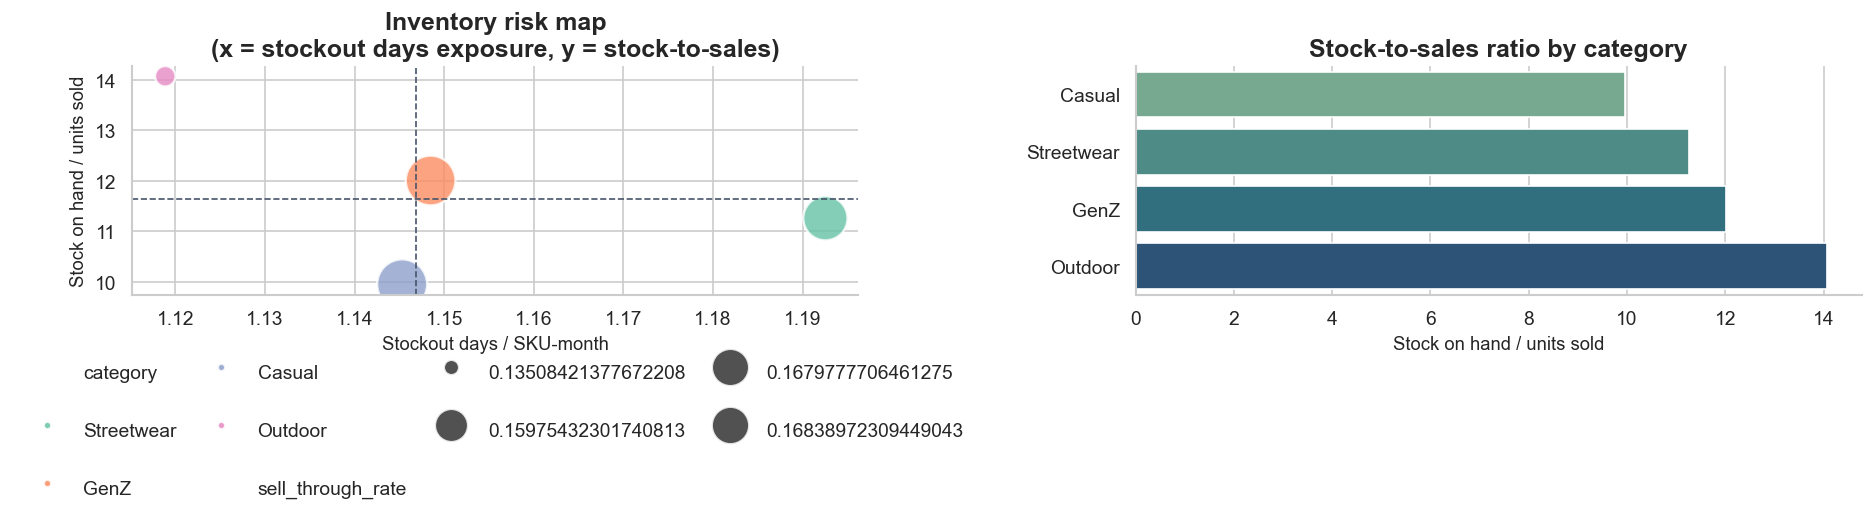

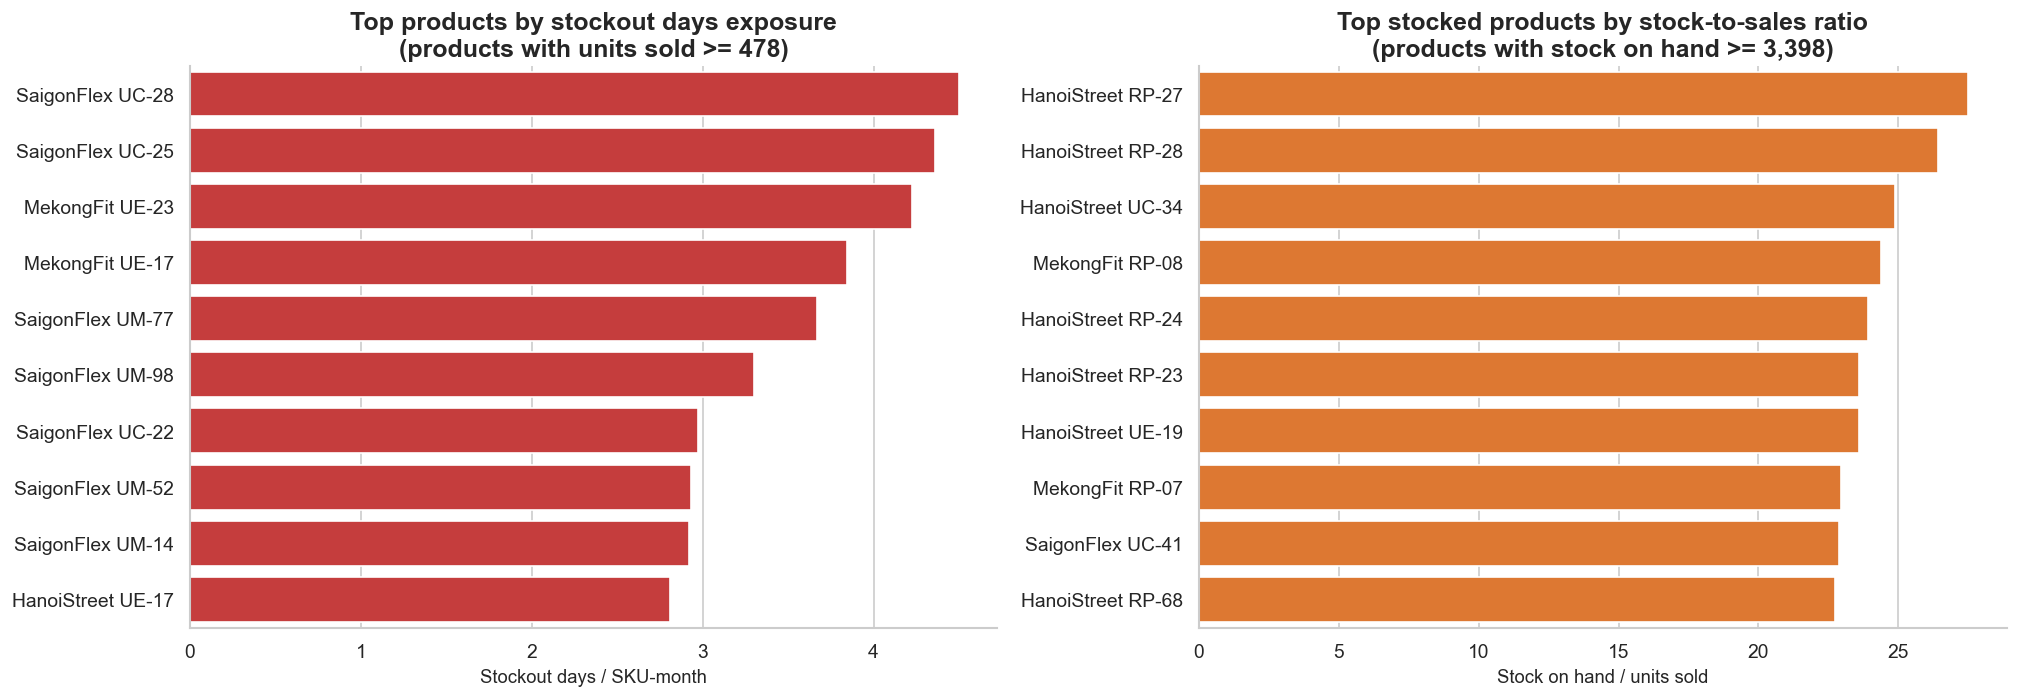

### Insight 7 - Có đồng thời rủi ro mất doanh thu và rủi ro kẹt vốn

- Category có stockout exposure cao nhất là **Streetwear** với **1.19 stockout days/SKU-month**.
- Category có stock-to-sales cao nhất là **Outdoor** với **14.07x**.
- Sau filter top-quartile units sold, product dễ mất doanh thu nhất là **SaigonFlex UC-28** với **4.50 stockout days/SKU-month**.
- Sau filter top-quartile stock, product kẹt vốn nhất là **HanoiStreet RP-27** với stock-to-sales **27.50x**.

**Business implication / action:** Tách inventory playbook: tăng reorder threshold cho nhóm stockout days cao + sell-through cao; clearance/giảm nhập cho nhóm stock-to-sales cao + sell-through thấp.

,category,sku_months,stock_on_hand,units_received,units_sold,stockout_days,avg_days_supply,fill_rate,stockout_rate,overstock_rate,reorder_rate,sell_through_rate,stockout_days_per_sku_month,stock_to_sales_ratio
3,Streetwear,"31,020","5,759,494","599,599","511,467","36,993",887.1,96.02%,67.32%,74.93%,0.00%,15.98%,1.19,11.26
1,GenZ,"4,674","584,757","56,311","48,695","5,368",718.8,96.17%,68.29%,71.63%,0.00%,16.80%,1.15,12.01
0,Casual,"3,503","310,522","35,788","31,202","4,012",459.1,96.18%,66.20%,72.59%,0.00%,16.84%,1.15,9.95
2,Outdoor,"21,050","4,749,891","395,568","337,510","23,552","1,068.8",96.27%,67.35%,79.85%,0.00%,13.51%,1.12,14.07


In [10]:
inv_summary = inventory.groupby("category", as_index=False).agg(
    sku_months=("snapshot_date", "count"),
    stock_on_hand=("stock_on_hand", "sum"),
    units_received=("units_received", "sum"),
    units_sold=("units_sold", "sum"),
    stockout_days=("stockout_days", "sum"),
    avg_days_supply=("days_of_supply", "mean"),
    fill_rate=("fill_rate", "mean"),
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    reorder_rate=("reorder_flag", "mean"),
    sell_through_rate=("sell_through_rate", "mean"),
)
inv_summary["stockout_days_per_sku_month"] = safe_divide(inv_summary["stockout_days"], inv_summary["sku_months"])
inv_summary["stock_to_sales_ratio"] = safe_divide(inv_summary["stock_on_hand"], inv_summary["units_sold"])
inv_summary = inv_summary.sort_values("stockout_days_per_sku_month", ascending=False)

product_inv = inventory.groupby(["product_id", "product_name", "category", "segment"], as_index=False).agg(
    sku_months=("snapshot_date", "count"),
    units_sold=("units_sold", "sum"),
    stock_on_hand=("stock_on_hand", "sum"),
    stockout_days=("stockout_days", "sum"),
    avg_days_supply=("days_of_supply", "mean"),
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    sell_through_rate=("sell_through_rate", "mean"),
    fill_rate=("fill_rate", "mean"),
)
product_inv["stockout_days_per_sku_month"] = safe_divide(product_inv["stockout_days"], product_inv["sku_months"])
product_inv["stock_to_sales_ratio"] = safe_divide(product_inv["stock_on_hand"], product_inv["units_sold"])

MIN_PRODUCT_UNITS_SOLD = int(product_inv["units_sold"].quantile(0.75))
MIN_PRODUCT_STOCK_ON_HAND = int(product_inv["stock_on_hand"].quantile(0.75))
stockout_product_pool = product_inv.loc[product_inv["units_sold"] >= MIN_PRODUCT_UNITS_SOLD].copy()
overstock_product_pool = product_inv.loc[product_inv["stock_on_hand"] >= MIN_PRODUCT_STOCK_ON_HAND].copy()
top_stockout_products = stockout_product_pool.sort_values(
    ["stockout_days_per_sku_month", "sell_through_rate", "units_sold"],
    ascending=False,
).head(10)
top_overstock_products = overstock_product_pool.sort_values(
    ["stock_to_sales_ratio", "stock_on_hand"],
    ascending=False,
).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=inv_summary,
    x="stockout_days_per_sku_month",
    y="stock_to_sales_ratio",
    size="sell_through_rate",
    hue="category",
    sizes=(150, 900),
    alpha=0.8,
    ax=axes[0],
)
axes[0].axvline(inv_summary["stockout_days_per_sku_month"].median(), color=COLOR_GRAY, linewidth=1, linestyle="--")
axes[0].axhline(inv_summary["stock_to_sales_ratio"].median(), color=COLOR_GRAY, linewidth=1, linestyle="--")
axes[0].set_title("Inventory risk map\n(x = stockout days exposure, y = stock-to-sales)")
axes[0].set_xlabel("Stockout days / SKU-month")
axes[0].set_ylabel("Stock on hand / units sold")
style_bubble_legend(axes[0], loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=4)

sns.barplot(data=inv_summary.sort_values("stock_to_sales_ratio"), y="category", x="stock_to_sales_ratio", ax=axes[1], palette="crest")
axes[1].set_title("Stock-to-sales ratio by category")
axes[1].set_xlabel("Stock on hand / units sold")
axes[1].set_ylabel("")
plt.tight_layout(rect=[0, 0.14, 1, 1])
savefig("part2_13_inventory_risk_map.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=top_stockout_products, y="product_name", x="stockout_days_per_sku_month", ax=axes[0], color=COLOR_RED)
axes[0].set_title(f"Top products by stockout days exposure\n(products with units sold >= {MIN_PRODUCT_UNITS_SOLD:,})")
axes[0].set_xlabel("Stockout days / SKU-month")
axes[0].set_ylabel("")

sns.barplot(data=top_overstock_products, y="product_name", x="stock_to_sales_ratio", ax=axes[1], color=COLOR_ORANGE)
axes[1].set_title(f"Top stocked products by stock-to-sales ratio\n(products with stock on hand >= {MIN_PRODUCT_STOCK_ON_HAND:,})")
axes[1].set_xlabel("Stock on hand / units sold")
axes[1].set_ylabel("")
plt.tight_layout()
savefig("part2_14_inventory_product_risk.png")
plt.show()

stockout_cat = inv_summary.loc[inv_summary["stockout_days_per_sku_month"].idxmax()]
overstock_cat = inv_summary.loc[inv_summary["stock_to_sales_ratio"].idxmax()]
low_fill_cat = inv_summary.loc[inv_summary["fill_rate"].idxmin()]
best_sell_cat = inv_summary.loc[inv_summary["sell_through_rate"].idxmax()]
demand_at_risk_product = top_stockout_products.iloc[0]
capital_lock_product = top_overstock_products.iloc[0]

display_insight(
    "Insight 7 - Có đồng thời rủi ro mất doanh thu và rủi ro kẹt vốn",
    [
        f"Category có stockout exposure cao nhất là **{stockout_cat['category']}** với **{stockout_cat['stockout_days_per_sku_month']:.2f} stockout days/SKU-month**.",
        f"Category có stock-to-sales cao nhất là **{overstock_cat['category']}** với **{overstock_cat['stock_to_sales_ratio']:.2f}x**.",
        f"Sau filter top-quartile units sold, product dễ mất doanh thu nhất là **{demand_at_risk_product['product_name']}** với **{demand_at_risk_product['stockout_days_per_sku_month']:.2f} stockout days/SKU-month**.",
        f"Sau filter top-quartile stock, product kẹt vốn nhất là **{capital_lock_product['product_name']}** với stock-to-sales **{capital_lock_product['stock_to_sales_ratio']:.2f}x**.",
    ],
    "Tách inventory playbook: tăng reorder threshold cho nhóm stockout days cao + sell-through cao; clearance/giảm nhập cho nhóm stock-to-sales cao + sell-through thấp.",
)
display_table(
    inv_summary,
    int_cols=["sku_months", "stock_on_hand", "units_received", "units_sold", "stockout_days"],
    pct_cols=["fill_rate", "stockout_rate", "overstock_rate", "reorder_rate", "sell_through_rate"],
    float_cols={"avg_days_supply": 1, "stockout_days_per_sku_month": 2, "stock_to_sales_ratio": 2},
)


## 10. Tổng hợp đề xuất

Bảng dưới đây chuyển insight thành hành động kinh doanh.

In [11]:
recommendations = pd.DataFrame([
    {
        "area": "Revenue planning",
        "evidence": f"Peak month {peak_month['year_month'].strftime('%Y-%m')} revenue {money(peak_month['revenue'])}; seasonal peak month {int(seasonal_peak['month'])}",
        "action": "Chuẩn bị inventory/logistics trước seasonal peak; đặt margin guardrail cho campaign tháng cao điểm.",
    },
    {
        "area": "Product portfolio",
        "evidence": f"{top_profit_cat['category']} đóng góp {pct(top_profit_cat['profit_share'])} gross profit; {top_return_cat['category']} return cao nhất",
        "action": "Tăng phân bổ cho nhóm profit/margin tốt; audit nhóm return hoặc discount cao.",
    },
    {
        "area": "Promotion",
        "evidence": f"Promo lines chiếm {pct(promo_yes['rows'] / promo_perf['rows'].sum())} dòng; margin gap {pct(margin_gap)}",
        "action": "Chấm campaign bằng gross profit, margin gap và return rate; hạn chế discount đại trà nếu margin bị bào mòn.",
    },
    {
        "area": "Customer retention",
        "evidence": f"Median repeat gap {repeat_gaps.median():.0f} ngày; best acquisition {best_acq['acquisition_channel']} at {money(best_acq['avg_profit_per_buyer'])}/buyer",
        "action": "Thiết kế CRM trigger quanh repeat gap; tối ưu acquisition theo buyer rate, gross profit/signup và gross profit/buyer.",
    },
    {
        "area": "Returns and CX",
        "evidence": f"Top return reason {top_reason['return_reason']} ({pct(top_reason['record_share'])} records); worst size {worst_size['size']} unit return {pct(worst_size['unit_return_rate'])}",
        "action": "Tách action theo nguyên nhân: size guide, carrier SLA, QC/supplier; ưu tiên nơi refund/revenue cao.",
    },
    {
        "area": "Traffic",
        "evidence": f"Best bounce source {best_source['traffic_source']}; sessions-revenue corr {corr_sessions_revenue:.3f}",
        "action": "Dùng traffic làm leading indicator, nhưng scale ngân sách theo quality metrics và conversion proxy.",
    },
    {
        "area": "Inventory",
        "evidence": f"{stockout_cat['category']} stockout exposure {stockout_cat['stockout_days_per_sku_month']:.2f} days/SKU-month; {overstock_cat['category']} stock-to-sales {overstock_cat['stock_to_sales_ratio']:.2f}x",
        "action": "Tăng reorder threshold cho nhóm stockout exposure cao; clearance/giảm nhập cho nhóm stock-to-sales cao.",
    },
])
display(recommendations)


,area,evidence,action
0,Revenue planning,Peak month 2018-06 revenue 271.67M; seasonal p...,Chuẩn bị inventory/logistics trước seasonal pe...
1,Product portfolio,Streetwear đóng góp 76.8% gross profit; GenZ r...,Tăng phân bổ cho nhóm profit/margin tốt; audit...
2,Promotion,Promo lines chiếm 38.7% dòng; margin gap -35.5%,"Chấm campaign bằng gross profit, margin gap và..."
3,Customer retention,Median repeat gap 156 ngày; best acquisition s...,Thiết kế CRM trigger quanh repeat gap; tối ưu ...
4,Returns and CX,Top return reason wrong_size (35.0% records); ...,"Tách action theo nguyên nhân: size guide, carr..."
5,Traffic,Best bounce source email_campaign; sessions-re...,"Dùng traffic làm leading indicator, nhưng scal..."
6,Inventory,Streetwear stockout exposure 1.19 days/SKU-mon...,Tăng reorder threshold cho nhóm stockout expos...
